# 07 — Auditoria, estacionariedade, grupos e tipologias

TCC de Isabella Viana Bambirra · UFSCar. Fontes: SCR/BACEN e Atlas consolidado v1.0 (14/04/2025). Este notebook executa a inspeção das duas bases e os testes em cada recorte, sem modificar os notebooks 05 e 06.

# Ampliação por grupos e tipologias — decisões metodológicas

## Fontes, unidade e auditoria

Entradas locais: `data/processed/df_tcc_2013_2024.parquet` e `data/raw/atlas_desastres/BD_Atlas_1991_2024_v1.0_2025.04.14_Consolidado.csv`. O consolidado do Atlas foi lido como Latin-1, separado por ponto e vírgula; Data_Evento usa dia/mês/ano. Data_Registro não substitui a data da ocorrência. Os hashes SHA256 e o dicionário de colunas/tipos/ausentes ficam nas tabelas da auditoria.

A unidade é **protocolo municipal único** (`Protocolo_S2iD` após remover espaços externos), conforme a decisão do chat “Inspeção de contagem de desastres”, novamente verificada nas bases. Entre 2013 e 2024 há 40.339 protocolos distintos, sem protocolos ausentes ou repetidos. Os 101 registros excedentes na chave município/data/COBRADE têm protocolos distintos: são preservados. Não há identificador validado para reconstruir um fenômeno físico que atinge vários municípios. Os resultados referem-se a registros municipais, não a 40.339 fenômenos independentes.

`grupo_de_desastre` e `descricao_tipologia` são preservados, removendo apenas espaços externos. “Outros” é uma categoria original, não um agrupamento criado aqui. Tipologias como Chuvas Intensas e Onda de Frio aparecem em mais de um grupo: essa classificação original é mantida e explicitada na tabela cruzada. Grupo e tipologia são duas classificações dos mesmos registros; suas somas reconciliam separadamente com o total, mas não devem ser somadas entre si.

A extração consolidada cobre 1991–2024 e contém registros em todos os meses de 2013–2024. O calendário é completado para todas as categorias. Um zero significa **nenhum protocolo observado na extração** naquele mês/categoria, não ausência certificada de fenômenos físicos. Não há painel independente da completude das notificações; subnotificação continua possível. Datas inválidas, protocolos ausentes/repetidos ou lacunas nacionais interrompem o código, em vez de virarem zeros silenciosos. Categorias ausentes são explicitadas como “Sem informação”, caso existam.

O Parquet tem 3.888 linhas, uma por UF × mês (27 × 144). A reconciliação compara, em cada uma dessas células, o total e todas as categorias: as divergências são zero. A taxa nacional é `100 * soma(carteira_inadimplencia_total) / soma(carteira_ativa_total)`, calculada uma única vez, **antes** de combinar com as séries de categorias. Não se faz média de taxas. O Parquet não contém a dimensão modalidade: a unicidade UF × mês garante que esta agregação não multiplica carteiras. Sem os CSVs brutos do SCR, não é possível certificar ausência de sobreposição de modalidades na origem. O script histórico `src/01_consolidar_scr.py` filtra PF e soma as linhas; essa limitação é expressa, não apresentada como uma auditoria concluída da origem.

## Recortes e estacionariedade

Total: janeiro/2013–dezembro/2024 (144 meses). Pré-pandemia: janeiro/2013–janeiro/2020 (85 meses). Cada transformação é calculada **dentro** do recorte. Primeira diferença perde 1 mês (143/84); diferença sazonal das primeiras diferenças perde 13 (131/72). As defasagens do modelo geram perdas adicionais.

ADF: constante, `autolag='AIC'`, máximo padrão de Schwert do statsmodels. ADF H0: raiz unitária. KPSS: constante, `nlags='auto'`; H0: estacionariedade em nível. Estatísticas, defasagens, n da série e n efetivo do ADF estão registrados. P-valores KPSS no limite da tabela são apresentados como limites (≤0,01 ou ≥0,10), não probabilidades exatas. Os avisos são preservados nas tabelas.

São avaliados nível, log (log1p para contagens), primeira diferença, diferença do log, diferença sazonal, primeira diferença seguida de sazonal e diferença do log seguida de sazonal. ADF rejeita e KPSS não rejeita: convergência favorável; o contrário: convergência desfavorável; demais casos são distinguidos entre conflito e inconclusão. Uma classificação favorável não prova estacionariedade, especialmente em séries esparsas. STL robusta e perfis mensais descrevem sazonalidade; não provam raiz unitária sazonal. ACF sazonal negativa após diferenciação pode indicar sobrediferenciação.

Mantêm-se as transformações históricas ΔI e Δlog(1+D) para comparabilidade. Quando ADF/KPSS não convergem, o modelo é **exploratório**, explicitamente marcado e não qualificado como achado robusto. Não há busca por transformações para obter significância. Não se suprime a limitação mudando automaticamente a transformação; as alternativas diagnosticadas permitem uma etapa futura de modelagem específica.

Critério operacional pré-especificado de raridade: menos de 12 meses positivos **ou** menos de 24 protocolos no recorte. É uma cautela analítica, não um teorema de tamanho amostral. Séries raras permanecem nas descritivas e ADF/KPSS, mas não recebem inferência Granger convencional. Séries constantes não admitem os testes. Nenhuma categoria é fundida.



In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from apresentacao_categorias import *


In [2]:
series, meta, auditoria = preparar()
tabela(auditoria)
tabela(ambiente())

,Verificação,Resultado
0,SHA256 BD_Atlas_1991_2024_v1.0_2025.04.14_Consolidado.csv,6ca29008a60a30e9f45d0f451da7750f850d8902704487798e1ef39ca3da44af
1,SHA256 df_tcc_2013_2024.parquet,49991105866dc140e959bfd9200b780c76edae0b8c95c31040bcdbde7811afe5
2,Linhas Atlas completo,71929
3,Colunas Atlas,70
4,Colunas Parquet,33
5,Datas inválidas Atlas,0
6,Cobertura arquivo Atlas,1991-01-07 a 2024-12-31
7,Ausentes no recorte: Protocolo_S2iD,0
8,Ausentes no recorte: Sigla_UF,0
9,Ausentes no recorte: grupo_de_desastre,0


,Pacote,Versão
0,Python,3.12.14
1,numpy,2.3.5
2,pandas,2.2.3
3,scipy,1.17.0
4,statsmodels,0.15.0
5,matplotlib,3.10.8
6,plotly,7.1.0
7,pyarrow,25.0.1
8,nbformat,5.11.1
9,nbclient,0.11.0


## Reconciliação com a série anterior

A comparação é feita nas 3.888 células UF × mês, além da soma nacional. As carteiras são somadas uma única vez; grupo e tipologia não multiplicam a carteira.

In [3]:
tabela(ler('reconciliacao'))
tabela(ler('classificacao_grupo_tipologia'))

,Nível,Categoria,Total Atlas,Total Parquet,Células UF × mês divergentes,Diferença máxima
0,Referência,Total nacional,40339,40339,0,0.0
1,Grupo,Climatológico,19518,19518,0,0.0
2,Grupo,Hidrológico,15409,15409,0,0.0
3,Grupo,Meteorológico,3716,3716,0,0.0
4,Grupo,Outros,1696,1696,0,0.0
5,Tipologia,Alagamentos,1504,1504,0,0.0
6,Tipologia,Chuvas Intensas,8084,8084,0,0.0
7,Tipologia,Doenças infecciosas,243,243,0,0.0
8,Tipologia,Enxurradas,2759,2759,0,0.0
9,Tipologia,Erosão,480,480,0,0.0


,grupo_de_desastre,descricao_tipologia,Protocolos
0,Climatológico,Chuvas Intensas,106
1,Climatológico,Estiagem e Seca,16149
2,Climatológico,Incêndio Florestal,3081
3,Climatológico,Onda de Frio,182
4,Hidrológico,Alagamentos,1504
5,Hidrológico,Chuvas Intensas,7978
6,Hidrológico,Enxurradas,2759
7,Hidrológico,Inundações,2065
8,Hidrológico,Movimento de Massa,1103
9,Meteorológico,Granizo,1070


## Execução dos diagnósticos

O calendário completo descreve a extração disponível. Zeros são ausência de protocolos observados, sujeitos à subnotificação. As tabelas seguintes incluem categorias raras, sem fundi-las.

In [4]:
cobertura, testes, sazonalidade = estacionariedade(series,meta)
tabela(cobertura)
tabela(sazonalidade)

,Período,Chave,Nível,Categoria,Meses,Início,Fim,Total ocorrências,Meses com ocorrência,Proporção zeros,Média,Desvio-padrão,Variância,Valores distintos,Rara,Elegível Granger,Cobertura
0,Total (2013–2024),Inadimplência,Crédito,Inadimplência,144,2013-01-01,2024-12-01,NaN,144,0.000000,3.842491,0.457574,0.209374,144,False,True,27 UFs em todos os meses
1,Total (2013–2024),Total nacional,Referência,Total nacional,144,2013-01-01,2024-12-01,40339.0,144,0.000000,280.131944,188.756447,35628.996455,126,False,True,Extração disponível; notificação completa não certificada
2,Total (2013–2024),Grupo | Climatológico,Grupo,Climatológico,144,2013-01-01,2024-12-01,19518.0,144,0.000000,135.541667,115.726944,13392.725524,106,False,True,Extração disponível; notificação completa não certificada
3,Total (2013–2024),Grupo | Hidrológico,Grupo,Hidrológico,144,2013-01-01,2024-12-01,15409.0,144,0.000000,107.006944,114.970990,13218.328623,103,False,True,Extração disponível; notificação completa não certificada
4,Total (2013–2024),Grupo | Meteorológico,Grupo,Meteorológico,144,2013-01-01,2024-12-01,3716.0,144,0.000000,25.805556,31.914282,1018.521368,56,False,True,Extração disponível; notificação completa não certificada
5,Total (2013–2024),Grupo | Outros,Grupo,Outros,144,2013-01-01,2024-12-01,1696.0,141,0.020833,11.777778,11.542227,133.222999,32,False,True,Extração disponível; notificação completa não certificada
6,Total (2013–2024),Tipologia | Alagamentos,Tipologia,Alagamentos,144,2013-01-01,2024-12-01,1504.0,138,0.041667,10.444444,9.810639,96.248640,31,False,True,Extração disponível; notificação completa não certificada
7,Total (2013–2024),Tipologia | Chuvas Intensas,Tipologia,Chuvas Intensas,144,2013-01-01,2024-12-01,8084.0,142,0.013889,56.138889,81.314516,6612.050505,78,False,True,Extração disponível; notificação completa não certificada
8,Total (2013–2024),Tipologia | Doenças infecciosas,Tipologia,Doenças infecciosas,144,2013-01-01,2024-12-01,243.0,45,0.687500,1.687500,9.153293,83.782780,10,False,True,Extração disponível; notificação completa não certificada
9,Total (2013–2024),Tipologia | Enxurradas,Tipologia,Enxurradas,144,2013-01-01,2024-12-01,2759.0,136,0.055556,19.159722,20.558177,422.638646,48,False,True,Extração disponível; notificação completa não certificada


,Período,Chave,Nível,Categoria,ACF(12) nível,Força sazonal STL,Nota
0,Total (2013–2024),Inadimplência,Crédito,Inadimplência,0.306588,1.399633e-01,STL descritiva; não é teste de raiz sazonal
1,Total (2013–2024),Total nacional,Referência,Total nacional,0.237973,2.027844e-01,STL descritiva; não é teste de raiz sazonal
2,Total (2013–2024),Grupo | Climatológico,Grupo,Climatológico,0.173585,2.844122e-01,STL descritiva; não é teste de raiz sazonal
3,Total (2013–2024),Grupo | Hidrológico,Grupo,Hidrológico,0.297857,2.948199e-01,STL descritiva; não é teste de raiz sazonal
4,Total (2013–2024),Grupo | Meteorológico,Grupo,Meteorológico,0.167695,1.670131e-01,STL descritiva; não é teste de raiz sazonal
5,Total (2013–2024),Grupo | Outros,Grupo,Outros,0.492690,5.092445e-02,STL descritiva; não é teste de raiz sazonal
6,Total (2013–2024),Tipologia | Alagamentos,Tipologia,Alagamentos,0.323250,4.174504e-01,STL descritiva; não é teste de raiz sazonal
7,Total (2013–2024),Tipologia | Chuvas Intensas,Tipologia,Chuvas Intensas,0.351616,1.917987e-01,STL descritiva; não é teste de raiz sazonal
8,Total (2013–2024),Tipologia | Doenças infecciosas,Tipologia,Doenças infecciosas,0.549306,0.000000e+00,STL descritiva; não é teste de raiz sazonal
9,Total (2013–2024),Tipologia | Enxurradas,Tipologia,Enxurradas,0.107588,9.831034e-02,STL descritiva; não é teste de raiz sazonal


## Leitura por série e período

Cada painel mostra nível, perfil sazonal, transformações de referência e suas ACFs. A tabela mantém todas as transformações avaliadas; a interpretação destaca as duas que entram em Granger.

### Inadimplência — Total (2013–2024)

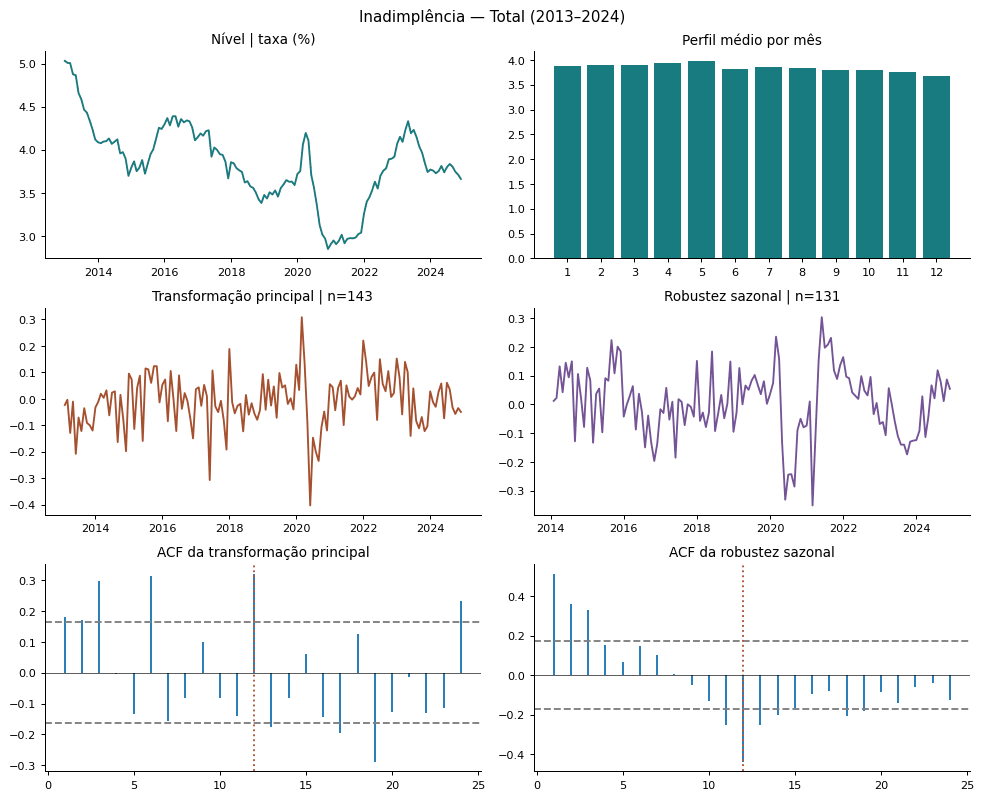

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
0,Nível,144,0,-2.210006,0.202634,13,130,0.696208,0.013890,8,Interpolado,Não estacionária: convergente
1,Log,144,0,-2.229374,0.195757,13,130,0.661701,0.017027,8,Interpolado,Não estacionária: convergente
2,Primeira diferença,143,1,-3.215386,0.019111,12,130,0.161144,0.100000,6,"p ≥ 0,10",Estacionária: convergente
3,Diferença do log,143,1,-3.185949,0.020813,12,130,0.130614,0.100000,7,"p ≥ 0,10",Estacionária: convergente
4,Diferença sazonal,132,12,-2.758369,0.064471,13,118,0.203038,0.100000,6,"p ≥ 0,10",Inconclusiva: nenhum rejeita
5,Diferença + sazonal,131,13,-3.860336,0.002347,12,118,0.086882,0.100000,5,"p ≥ 0,10",Estacionária: convergente
6,Diferença do log + sazonal,131,13,-3.895427,0.002069,12,118,0.071390,0.100000,5,"p ≥ 0,10",Estacionária: convergente


**Primeira diferença:** Estacionária: convergente; ADF p=0.01911, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença + sazonal:** Estacionária: convergente; ADF p=0.002347, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Inadimplência — Pré-pandemia (até jan/2020)

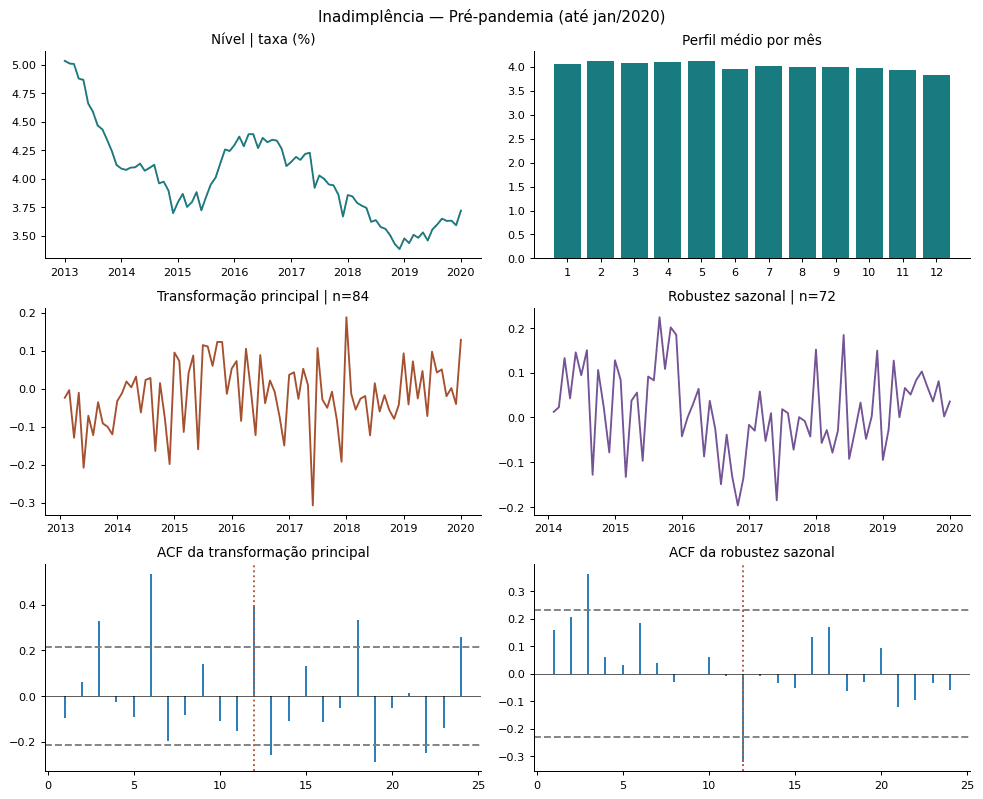

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
154,Nível,85,0,-2.468750,0.123264,6,78,0.901036,0.01,5,"p ≤ 0,01",Não estacionária: convergente
155,Log,85,0,-2.473387,0.122085,6,78,0.915092,0.01,5,"p ≤ 0,01",Não estacionária: convergente
156,Primeira diferença,84,1,-1.970285,0.299752,5,78,0.314327,0.10,0,"p ≥ 0,10",Inconclusiva: nenhum rejeita
157,Diferença do log,84,1,-1.877176,0.342873,5,78,0.287647,0.10,1,"p ≥ 0,10",Inconclusiva: nenhum rejeita
158,Diferença sazonal,73,12,-2.384365,0.146198,3,69,0.188598,0.10,5,"p ≥ 0,10",Inconclusiva: nenhum rejeita
159,Diferença + sazonal,72,13,-2.812048,0.056573,11,60,0.238163,0.10,3,"p ≥ 0,10",Inconclusiva: nenhum rejeita
160,Diferença do log + sazonal,72,13,-2.823596,0.054982,11,60,0.213407,0.10,3,"p ≥ 0,10",Inconclusiva: nenhum rejeita


**Primeira diferença:** Inconclusiva: nenhum rejeita; ADF p=0.2998, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença + sazonal:** Inconclusiva: nenhum rejeita; ADF p=0.05657, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Há transformação sem convergência entre os testes. Mantemos a especificação histórica para comparação, mas a inferência correspondente é exploratória e não entra na classificação de diagnósticos favoráveis.

### Total nacional — Total (2013–2024)

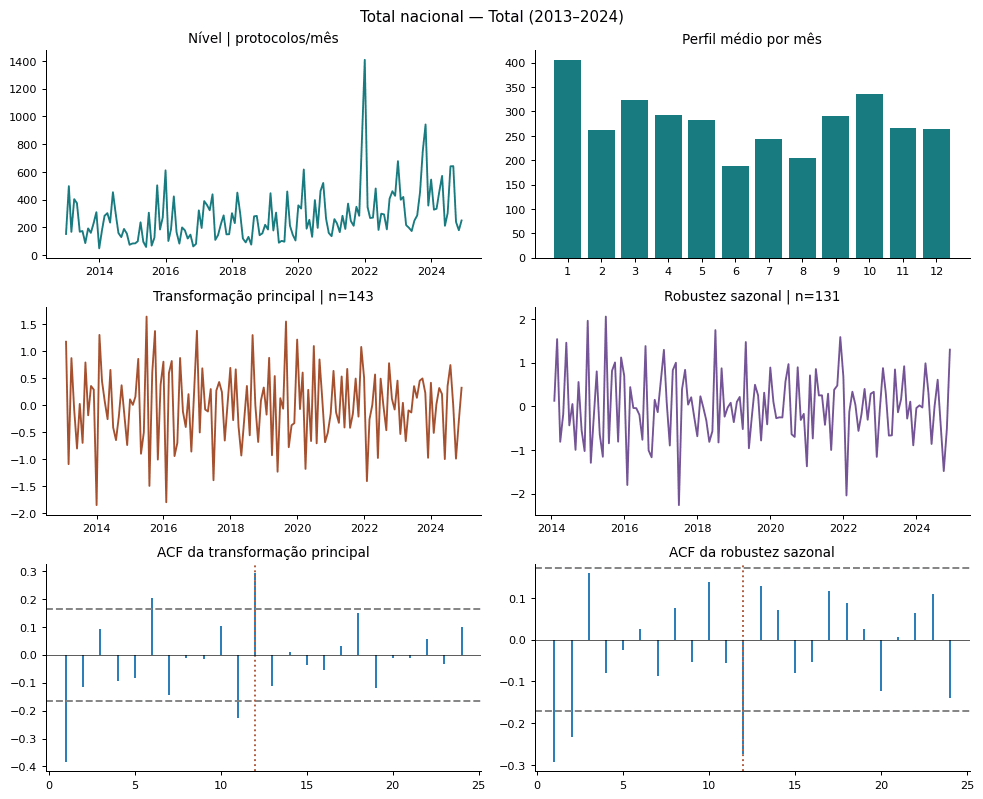

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
7,Nível,144,0,-7.977216,2.682296e-12,0,143,1.103765,0.01,5,"p ≤ 0,01",Conflitante: ambos rejeitam
8,Log,144,0,-1.422534,5.714268e-01,11,132,1.137314,0.01,6,"p ≤ 0,01",Não estacionária: convergente
9,Primeira diferença,143,1,-5.767554,5.487675e-07,12,130,0.110134,0.10,26,"p ≥ 0,10",Estacionária: convergente
10,Diferença do log,143,1,-6.965263,8.948856e-10,10,132,0.055823,0.10,14,"p ≥ 0,10",Estacionária: convergente
11,Diferença sazonal,132,12,-6.469638,1.377393e-08,11,120,0.073292,0.10,2,"p ≥ 0,10",Estacionária: convergente
12,Diferença + sazonal,131,13,-5.125826,1.243604e-05,13,117,0.232435,0.10,50,"p ≥ 0,10",Estacionária: convergente
13,Diferença do log + sazonal,131,13,-5.490216,2.183793e-06,13,117,0.328974,0.10,54,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=8.949e-10, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=2.184e-06, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Total nacional — Pré-pandemia (até jan/2020)

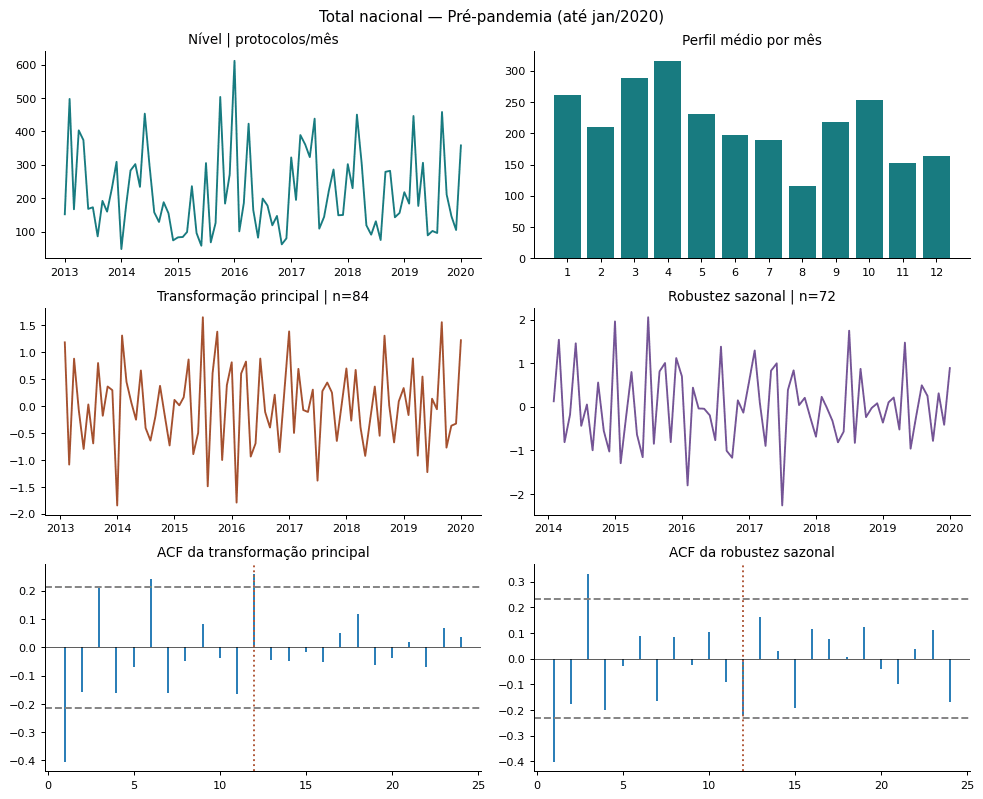

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
161,Nível,85,0,-3.983125,1.501498e-03,6,78,0.047868,0.1,1,"p ≥ 0,10",Estacionária: convergente
162,Log,85,0,-7.795684,7.729194e-12,0,84,0.067013,0.1,1,"p ≥ 0,10",Estacionária: convergente
163,Primeira diferença,84,1,-6.603860,6.631766e-09,4,79,0.134358,0.1,20,"p ≥ 0,10",Estacionária: convergente
164,Diferença do log,84,1,-5.113724,1.315500e-05,10,73,0.158992,0.1,25,"p ≥ 0,10",Estacionária: convergente
165,Diferença sazonal,73,12,-4.961443,2.644153e-05,11,61,0.066938,0.1,3,"p ≥ 0,10",Estacionária: convergente
166,Diferença + sazonal,72,13,-4.496988,1.991188e-04,12,59,0.155941,0.1,15,"p ≥ 0,10",Estacionária: convergente
167,Diferença do log + sazonal,72,13,-4.470170,2.225397e-04,12,59,0.192325,0.1,21,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.315e-05, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0002225, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Grupo | Climatológico — Total (2013–2024)

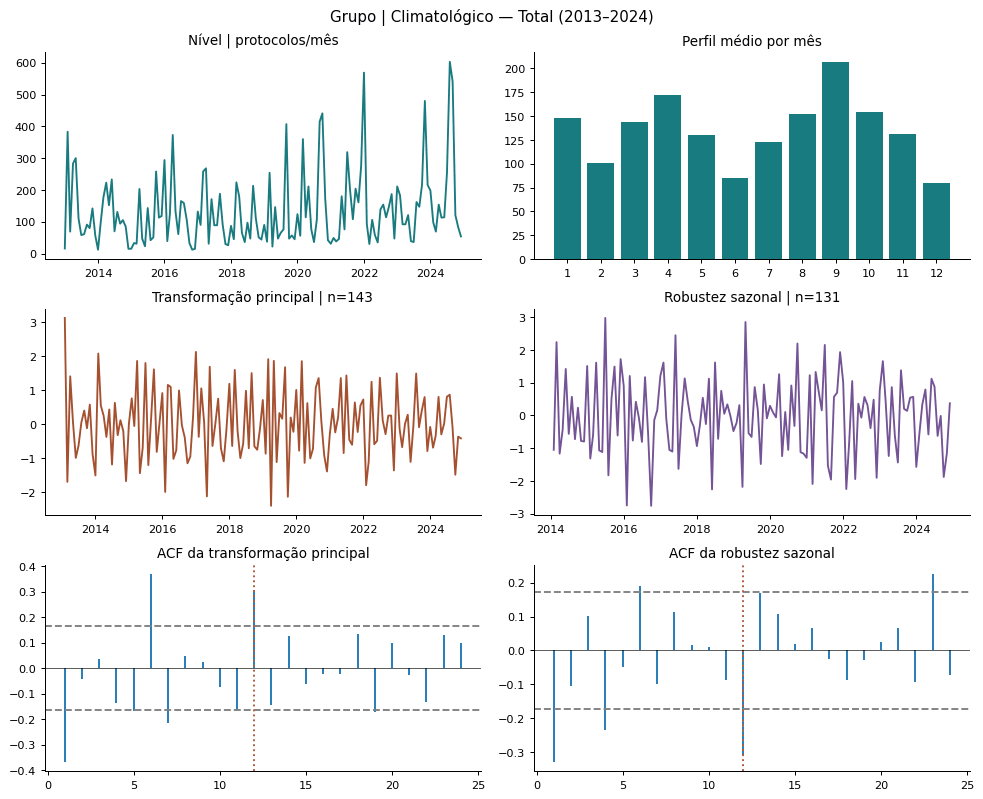

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
14,Nível,144,0,-4.510217,1.884483e-04,6,137,0.419942,0.068560,2,Interpolado,Estacionária: convergente
15,Log,144,0,-4.575287,1.434170e-04,6,137,0.455189,0.053367,3,Interpolado,Estacionária: convergente
16,Primeira diferença,143,1,-6.798443,2.269226e-09,10,132,0.087506,0.100000,15,"p ≥ 0,10",Estacionária: convergente
17,Diferença do log,143,1,-7.036665,5.991699e-10,10,132,0.124215,0.100000,11,"p ≥ 0,10",Estacionária: convergente
18,Diferença sazonal,132,12,-3.828644,2.627472e-03,12,119,0.087651,0.100000,2,"p ≥ 0,10",Estacionária: convergente
19,Diferença + sazonal,131,13,-5.314709,5.104287e-06,13,117,0.259741,0.100000,51,"p ≥ 0,10",Estacionária: convergente
20,Diferença do log + sazonal,131,13,-6.098089,9.987613e-08,13,117,0.136489,0.100000,23,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=5.992e-10, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=9.988e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Grupo | Climatológico — Pré-pandemia (até jan/2020)

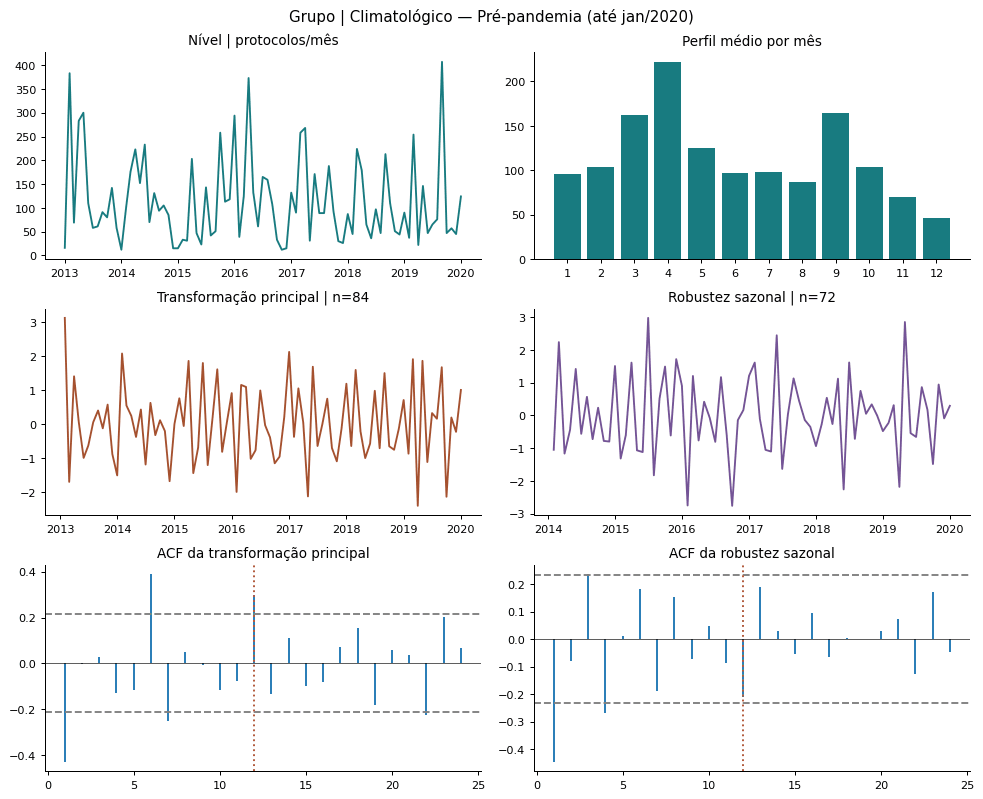

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
168,Nível,85,0,-2.393862,1.434763e-01,11,73,0.106447,0.1,0,"p ≥ 0,10",Inconclusiva: nenhum rejeita
169,Log,85,0,-3.964574,1.607803e-03,6,78,0.052893,0.1,2,"p ≥ 0,10",Estacionária: convergente
170,Primeira diferença,84,1,-6.190511,6.139142e-08,10,73,0.232988,0.1,31,"p ≥ 0,10",Estacionária: convergente
171,Diferença do log,84,1,-5.439326,2.799136e-06,10,73,0.160390,0.1,17,"p ≥ 0,10",Estacionária: convergente
172,Diferença sazonal,73,12,-3.581333,6.128098e-03,8,64,0.099604,0.1,2,"p ≥ 0,10",Estacionária: convergente
173,Diferença + sazonal,72,13,-13.869606,6.501367e-26,1,70,0.102405,0.1,13,"p ≥ 0,10",Estacionária: convergente
174,Diferença do log + sazonal,72,13,-4.408140,2.871401e-04,12,59,0.280629,0.1,40,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=2.799e-06, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0002871, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Grupo | Hidrológico — Total (2013–2024)

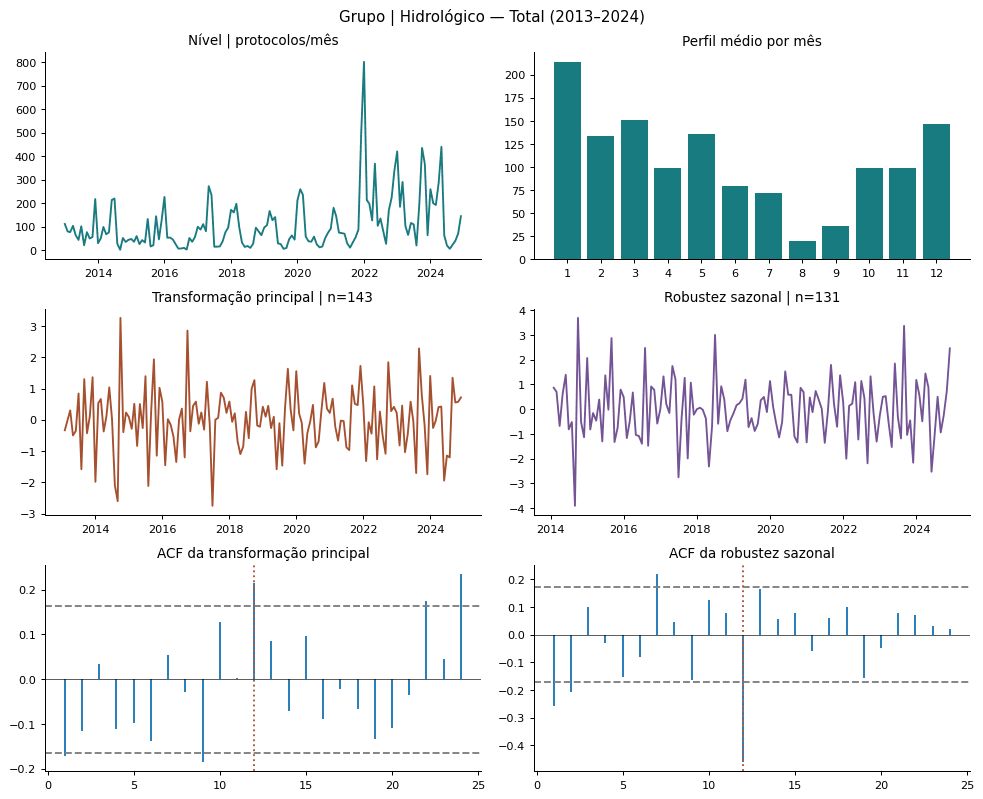

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
21,Nível,144,0,-1.626117,4.695240e-01,11,132,0.788871,0.010000,5,"p ≤ 0,01",Não estacionária: convergente
22,Log,144,0,-1.600048,4.835695e-01,11,132,0.525264,0.035977,6,Interpolado,Não estacionária: convergente
23,Primeira diferença,143,1,-7.324742,1.169011e-10,10,132,0.132619,0.100000,33,"p ≥ 0,10",Estacionária: convergente
24,Diferença do log,143,1,-8.499267,1.251130e-13,10,132,0.029120,0.100000,6,"p ≥ 0,10",Estacionária: convergente
25,Diferença sazonal,132,12,-3.949395,1.699947e-03,13,118,0.076202,0.100000,3,"p ≥ 0,10",Estacionária: convergente
26,Diferença + sazonal,131,13,-4.198181,6.635862e-04,11,119,0.269433,0.100000,68,"p ≥ 0,10",Estacionária: convergente
27,Diferença do log + sazonal,131,13,-6.322873,3.035818e-08,13,117,0.167818,0.100000,42,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.251e-13, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=3.036e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Grupo | Hidrológico — Pré-pandemia (até jan/2020)

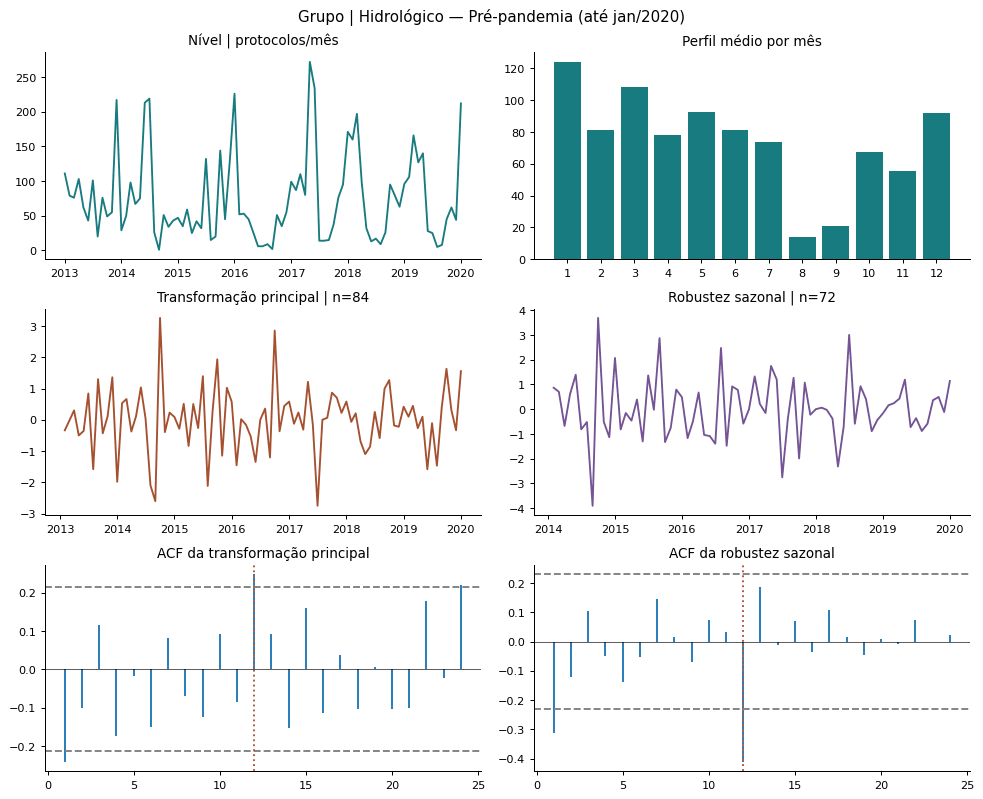

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
175,Nível,85,0,-5.341121,4.497904e-06,3,81,0.041286,0.1,3,"p ≥ 0,10",Estacionária: convergente
176,Log,85,0,-5.248243,7.002453e-06,3,81,0.059031,0.1,4,"p ≥ 0,10",Estacionária: convergente
177,Primeira diferença,84,1,-5.150637,1.107895e-05,10,73,0.277719,0.1,26,"p ≥ 0,10",Estacionária: convergente
178,Diferença do log,84,1,-6.221743,5.203207e-08,10,73,0.145948,0.1,10,"p ≥ 0,10",Estacionária: convergente
179,Diferença sazonal,73,12,-4.853636,4.289392e-05,11,61,0.053568,0.1,3,"p ≥ 0,10",Estacionária: convergente
180,Diferença + sazonal,72,13,-3.656975,4.760684e-03,12,59,0.262515,0.1,37,"p ≥ 0,10",Estacionária: convergente
181,Diferença do log + sazonal,72,13,-4.186642,6.940596e-04,12,59,0.171167,0.1,19,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=5.203e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0006941, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Grupo | Meteorológico — Total (2013–2024)

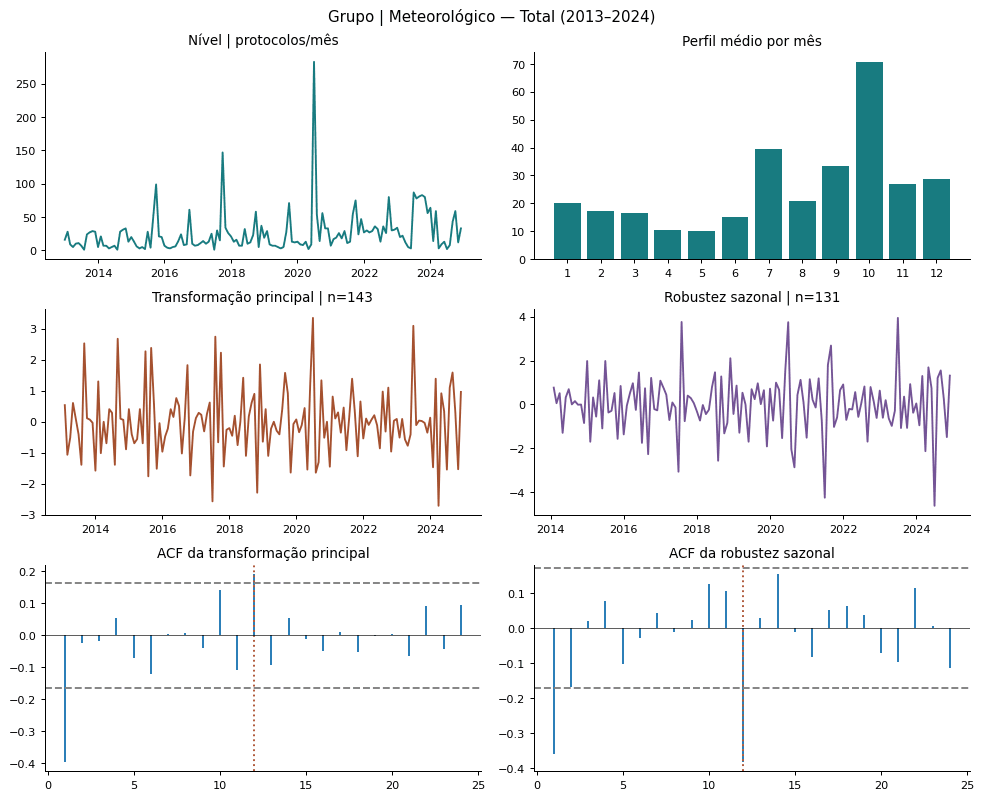

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
28,Nível,144,0,-9.655734,1.395822e-16,0,143,0.662464,0.016958,4,Interpolado,Conflitante: ambos rejeitam
29,Log,144,0,-1.688802,4.368913e-01,11,132,0.905049,0.010000,5,"p ≤ 0,01",Não estacionária: convergente
30,Primeira diferença,143,1,-6.760984,2.792713e-09,10,132,0.095742,0.100000,24,"p ≥ 0,10",Estacionária: convergente
31,Diferença do log,143,1,-7.799781,7.547232e-12,10,132,0.116171,0.100000,23,"p ≥ 0,10",Estacionária: convergente
32,Diferença sazonal,132,12,-6.142957,7.890194e-08,11,120,0.052698,0.100000,2,"p ≥ 0,10",Estacionária: convergente
33,Diferença + sazonal,131,13,-4.451611,2.402560e-04,12,118,0.428853,0.064718,110,Interpolado,Estacionária: convergente
34,Diferença do log + sazonal,131,13,-4.162438,7.622957e-04,12,118,0.237589,0.100000,51,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=7.547e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0007623, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Grupo | Meteorológico — Pré-pandemia (até jan/2020)

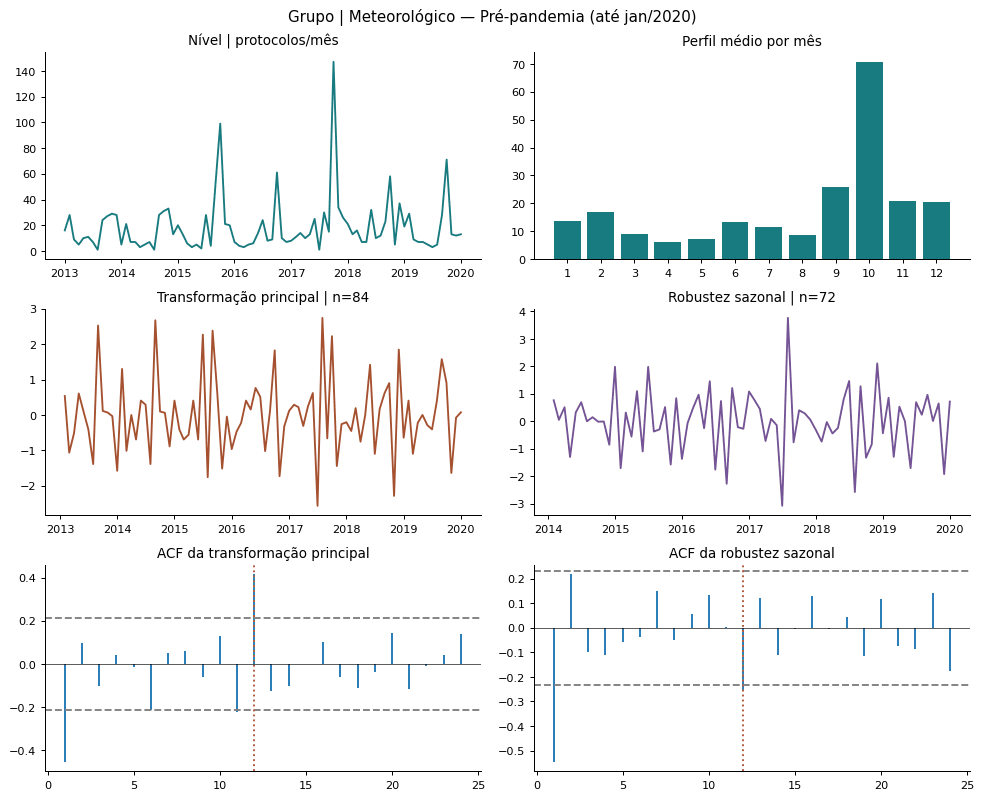

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
182,Nível,85,0,-1.934422,3.160453e-01,12,72,0.132267,0.1,2,"p ≥ 0,10",Inconclusiva: nenhum rejeita
183,Log,85,0,-1.486198,5.403277e-01,11,73,0.158103,0.1,3,"p ≥ 0,10",Inconclusiva: nenhum rejeita
184,Primeira diferença,84,1,-8.252318,5.349851e-13,10,73,0.084687,0.1,13,"p ≥ 0,10",Estacionária: convergente
185,Diferença do log,84,1,-7.509927,4.040805e-11,10,73,0.050009,0.1,7,"p ≥ 0,10",Estacionária: convergente
186,Diferença sazonal,73,12,-4.194668,6.727293e-04,11,61,0.089636,0.1,3,"p ≥ 0,10",Estacionária: convergente
187,Diferença + sazonal,72,13,-3.047729,3.067118e-02,12,59,0.059809,0.1,6,"p ≥ 0,10",Estacionária: convergente
188,Diferença do log + sazonal,72,13,-2.522264,1.101508e-01,10,61,0.037902,0.1,3,"p ≥ 0,10",Inconclusiva: nenhum rejeita


**Diferença do log:** Estacionária: convergente; ADF p=4.041e-11, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Inconclusiva: nenhum rejeita; ADF p=0.1102, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Há transformação sem convergência entre os testes. Mantemos a especificação histórica para comparação, mas a inferência correspondente é exploratória e não entra na classificação de diagnósticos favoráveis.

### Grupo | Outros — Total (2013–2024)

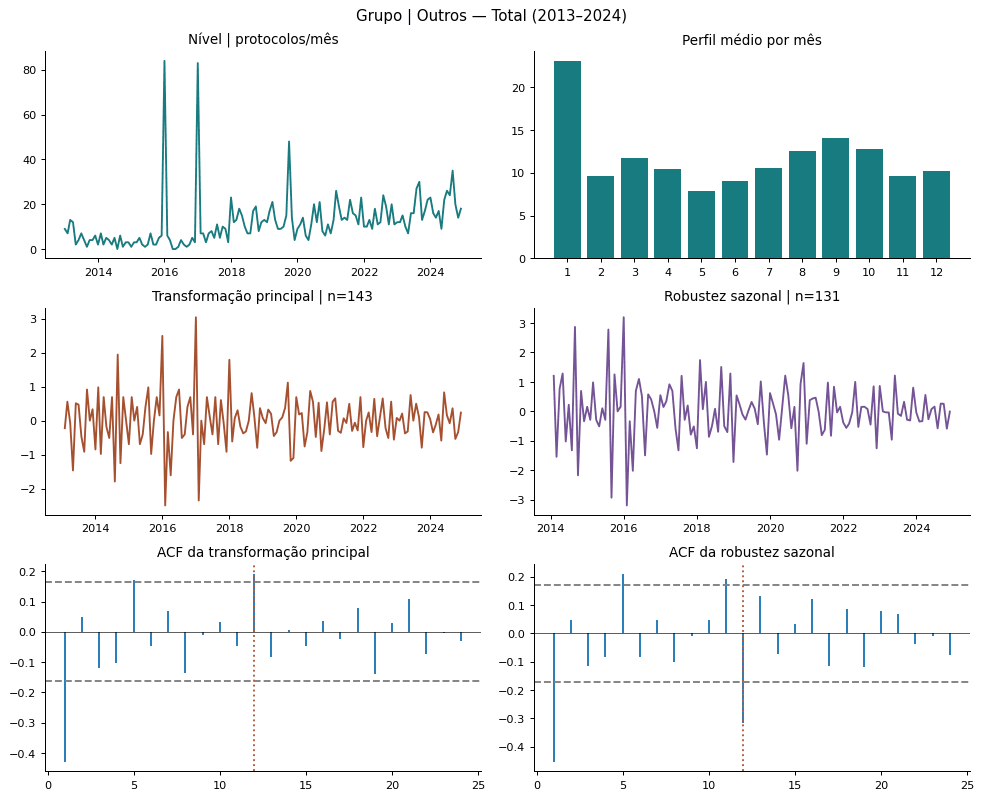

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
35,Nível,144,0,-1.022760,7.448728e-01,11,132,1.433818,0.010000,4,"p ≤ 0,01",Não estacionária: convergente
36,Log,144,0,-0.648701,8.595937e-01,11,132,1.438455,0.010000,7,"p ≤ 0,01",Não estacionária: convergente
37,Primeira diferença,143,1,-9.736800,8.706535e-17,10,132,0.444143,0.058128,127,Interpolado,Estacionária: convergente
38,Diferença do log,143,1,-6.965256,8.949207e-10,10,132,0.500000,0.041667,142,Interpolado,Conflitante: ambos rejeitam
39,Diferença sazonal,132,12,-10.644179,4.843284e-19,0,131,0.049682,0.100000,0,"p ≥ 0,10",Estacionária: convergente
40,Diferença + sazonal,131,13,-6.513157,1.087671e-08,8,122,0.144531,0.100000,27,"p ≥ 0,10",Estacionária: convergente
41,Diferença do log + sazonal,131,13,-4.535091,1.698397e-04,11,119,0.128720,0.100000,14,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Conflitante: ambos rejeitam; ADF p=8.949e-10, KPSS Interpolado (valor tabelado 0.042), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0001698, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Há transformação sem convergência entre os testes. Mantemos a especificação histórica para comparação, mas a inferência correspondente é exploratória e não entra na classificação de diagnósticos favoráveis.

### Grupo | Outros — Pré-pandemia (até jan/2020)

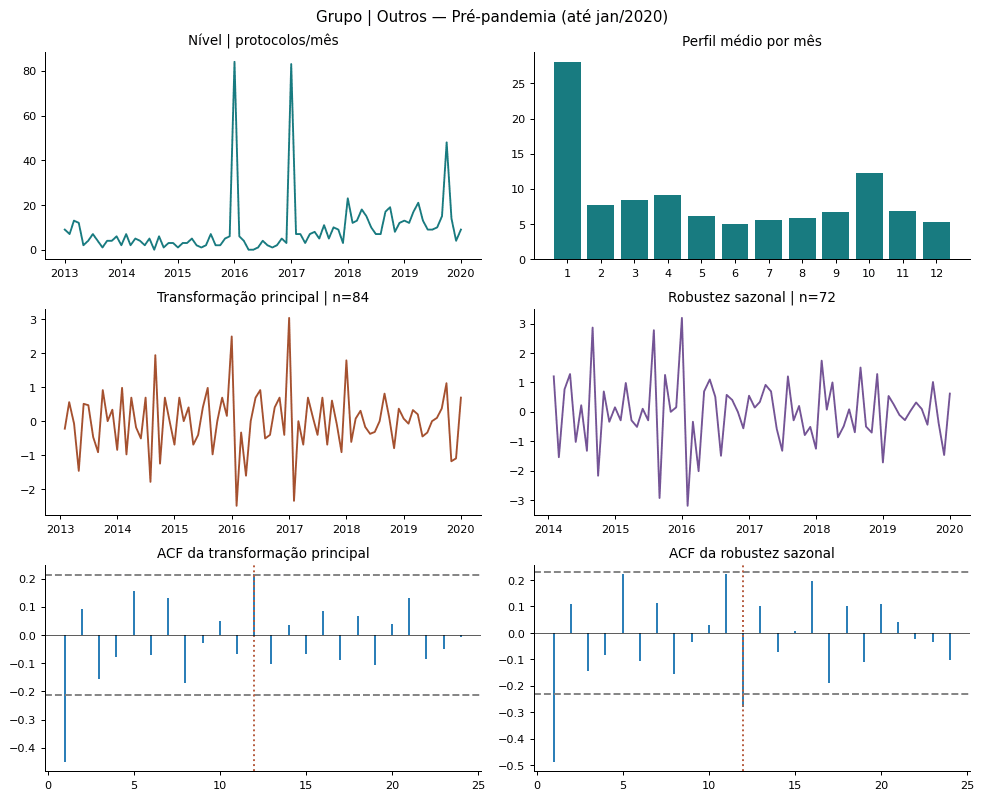

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
189,Nível,85,0,-0.929592,7.780712e-01,11,73,0.623994,0.020455,1,Interpolado,Não estacionária: convergente
190,Log,85,0,-1.904259,3.300601e-01,4,80,0.951711,0.010000,4,"p ≤ 0,01",Não estacionária: convergente
191,Primeira diferença,84,1,-7.377910,8.624592e-11,10,73,0.171569,0.100000,30,"p ≥ 0,10",Estacionária: convergente
192,Diferença do log,84,1,-8.101129,1.298966e-12,3,80,0.067109,0.100000,7,"p ≥ 0,10",Estacionária: convergente
193,Diferença sazonal,73,12,-8.037459,1.885878e-12,0,72,0.084691,0.100000,0,"p ≥ 0,10",Estacionária: convergente
194,Diferença + sazonal,72,13,-6.372721,2.323673e-08,4,67,0.176758,0.100000,19,"p ≥ 0,10",Estacionária: convergente
195,Diferença do log + sazonal,72,13,-8.047309,1.780241e-12,3,68,0.110098,0.100000,8,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.299e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=1.78e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Alagamentos — Total (2013–2024)

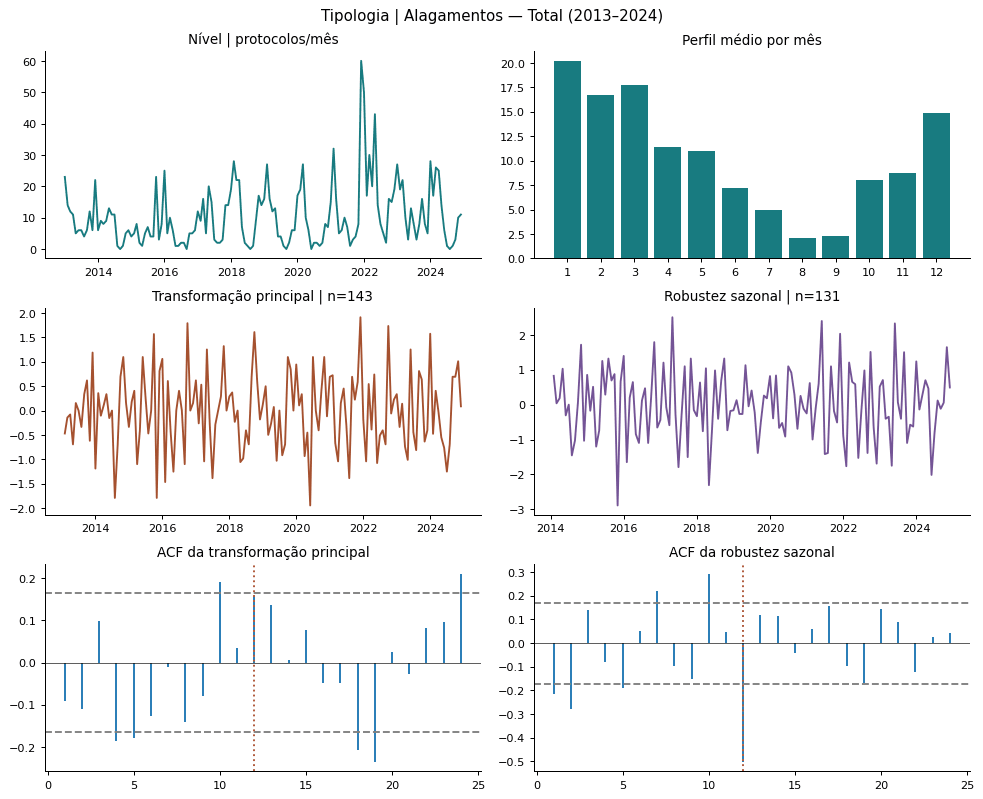

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
42,Nível,144,0,-2.319382,1.657931e-01,9,134,0.382353,0.084762,6,Interpolado,Inconclusiva: nenhum rejeita
43,Log,144,0,-2.127727,2.335127e-01,11,132,0.220513,0.100000,6,"p ≥ 0,10",Inconclusiva: nenhum rejeita
44,Primeira diferença,143,1,-9.645545,1.481243e-16,8,134,0.033748,0.100000,6,"p ≥ 0,10",Estacionária: convergente
45,Diferença do log,143,1,-7.771861,8.877312e-12,10,132,0.017012,0.100000,0,"p ≥ 0,10",Estacionária: convergente
46,Diferença sazonal,132,12,-5.036808,1.875668e-05,11,120,0.087862,0.100000,3,"p ≥ 0,10",Estacionária: convergente
47,Diferença + sazonal,131,13,-4.444812,2.470756e-04,13,117,0.171549,0.100000,35,"p ≥ 0,10",Estacionária: convergente
48,Diferença do log + sazonal,131,13,-6.008412,1.594898e-07,13,117,0.500000,0.041667,130,Interpolado,Conflitante: ambos rejeitam


**Diferença do log:** Estacionária: convergente; ADF p=8.877e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Conflitante: ambos rejeitam; ADF p=1.595e-07, KPSS Interpolado (valor tabelado 0.042), n=131.

Há transformação sem convergência entre os testes. Mantemos a especificação histórica para comparação, mas a inferência correspondente é exploratória e não entra na classificação de diagnósticos favoráveis.

### Tipologia | Alagamentos — Pré-pandemia (até jan/2020)

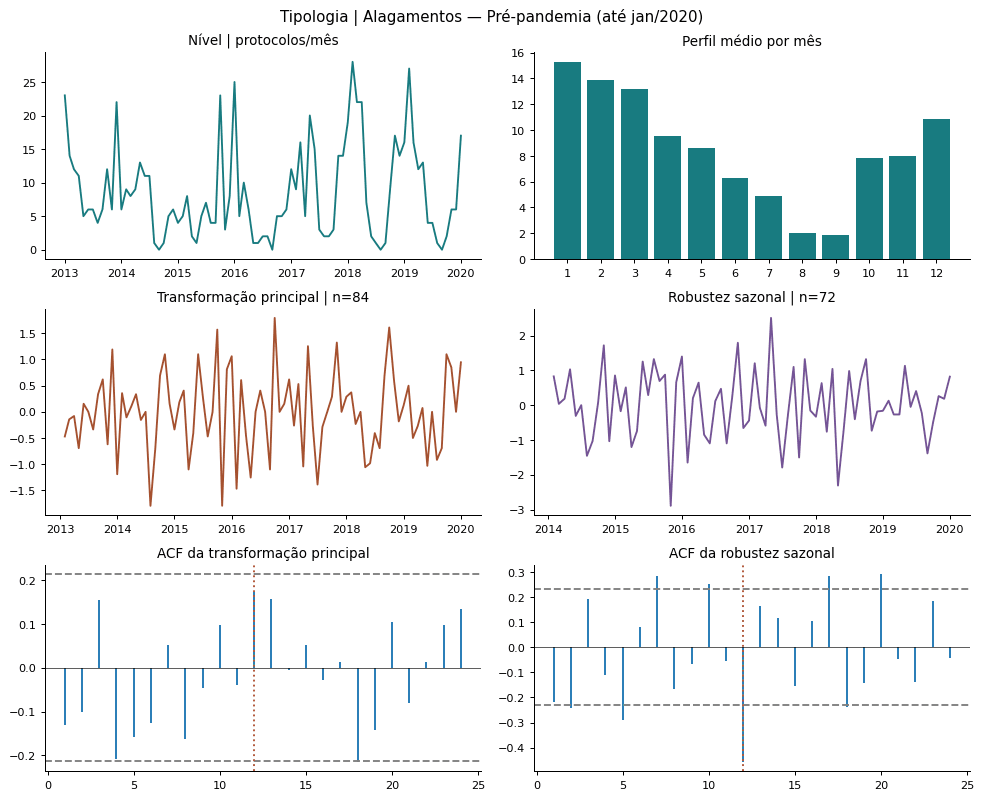

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
196,Nível,85,0,-5.667423,9.084030e-07,4,80,0.099608,0.100000,4,"p ≥ 0,10",Estacionária: convergente
197,Log,85,0,-5.696872,7.837341e-07,3,81,0.061198,0.100000,4,"p ≥ 0,10",Estacionária: convergente
198,Primeira diferença,84,1,-5.686778,8.244586e-07,9,74,0.122310,0.100000,7,"p ≥ 0,10",Estacionária: convergente
199,Diferença do log,84,1,-5.709546,7.353753e-07,10,73,0.063688,0.100000,5,"p ≥ 0,10",Estacionária: convergente
200,Diferença sazonal,73,12,-3.764798,3.288724e-03,11,61,0.147188,0.100000,3,"p ≥ 0,10",Estacionária: convergente
201,Diferença + sazonal,72,13,-3.354287,1.261952e-02,12,59,0.382297,0.084786,54,Interpolado,Estacionária: convergente
202,Diferença do log + sazonal,72,13,-4.041521,1.208041e-03,12,59,0.226826,0.100000,32,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=7.354e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.001208, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Chuvas Intensas — Total (2013–2024)

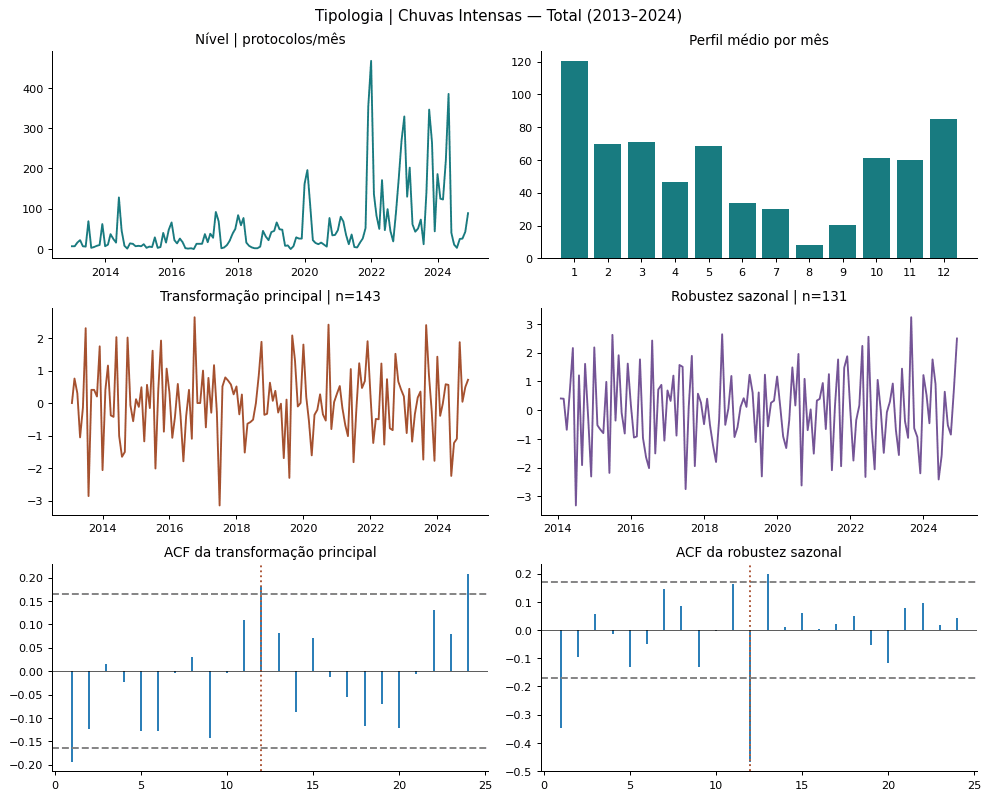

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
49,Nível,144,0,-0.902494,7.871500e-01,13,130,1.178131,0.010000,6,"p ≤ 0,01",Não estacionária: convergente
50,Log,144,0,-1.053887,7.331070e-01,11,132,1.184810,0.010000,7,"p ≤ 0,01",Não estacionária: convergente
51,Primeira diferença,143,1,-6.445737,1.567605e-08,12,130,0.173110,0.100000,51,"p ≥ 0,10",Estacionária: convergente
52,Diferença do log,143,1,-8.364414,2.767685e-13,10,132,0.037885,0.100000,9,"p ≥ 0,10",Estacionária: convergente
53,Diferença sazonal,132,12,-3.552455,6.737823e-03,13,118,0.077764,0.100000,2,"p ≥ 0,10",Estacionária: convergente
54,Diferença + sazonal,131,13,-4.041155,1.209697e-03,11,119,0.467464,0.048995,121,Interpolado,Conflitante: ambos rejeitam
55,Diferença do log + sazonal,131,13,-6.418275,1.818226e-08,13,117,0.085768,0.100000,26,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=2.768e-13, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=1.818e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Chuvas Intensas — Pré-pandemia (até jan/2020)

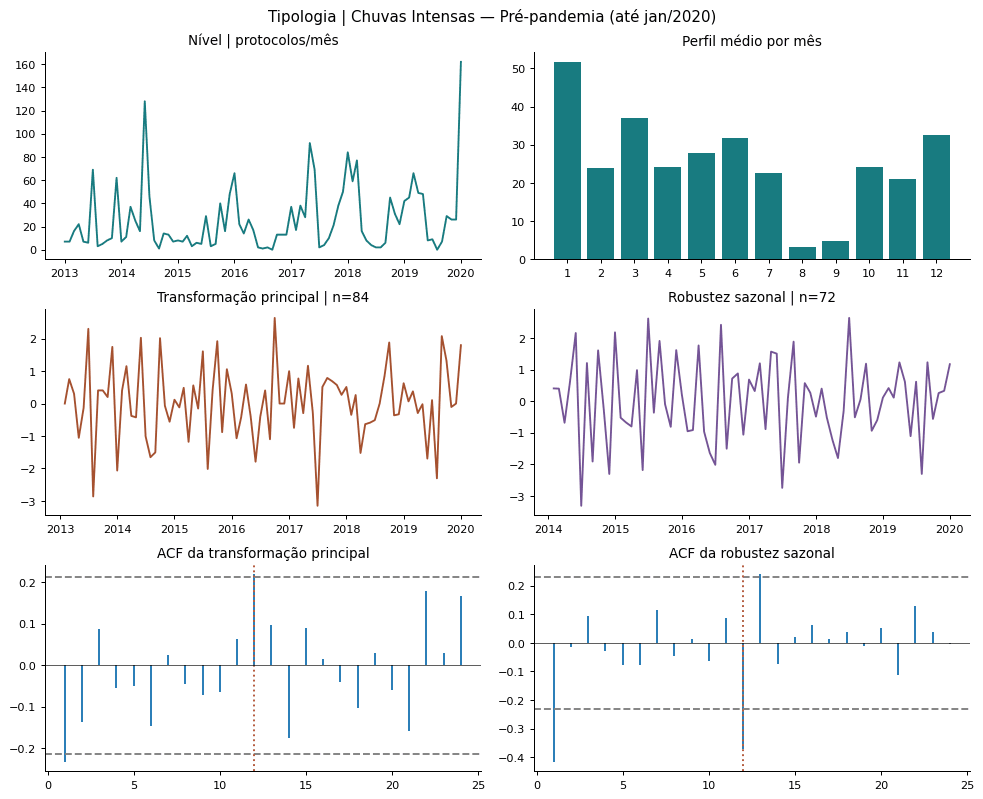

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
203,Nível,85,0,-5.206531,8.526144e-06,0,84,0.294525,0.1,3,"p ≥ 0,10",Estacionária: convergente
204,Log,85,0,-4.781248,5.906059e-05,4,80,0.160754,0.1,4,"p ≥ 0,10",Estacionária: convergente
205,Primeira diferença,84,1,-8.131780,1.085371e-12,1,82,0.223603,0.1,10,"p ≥ 0,10",Estacionária: convergente
206,Diferença do log,84,1,-6.311885,3.219593e-08,10,73,0.152332,0.1,12,"p ≥ 0,10",Estacionária: convergente
207,Diferença sazonal,73,12,-3.012847,3.371194e-02,12,60,0.066172,0.1,3,"p ≥ 0,10",Estacionária: convergente
208,Diferença + sazonal,72,13,-3.026123,3.252579e-02,11,60,0.161483,0.1,11,"p ≥ 0,10",Estacionária: convergente
209,Diferença do log + sazonal,72,13,-4.620606,1.183326e-04,11,60,0.168143,0.1,16,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=3.22e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0001183, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Doenças infecciosas — Total (2013–2024)

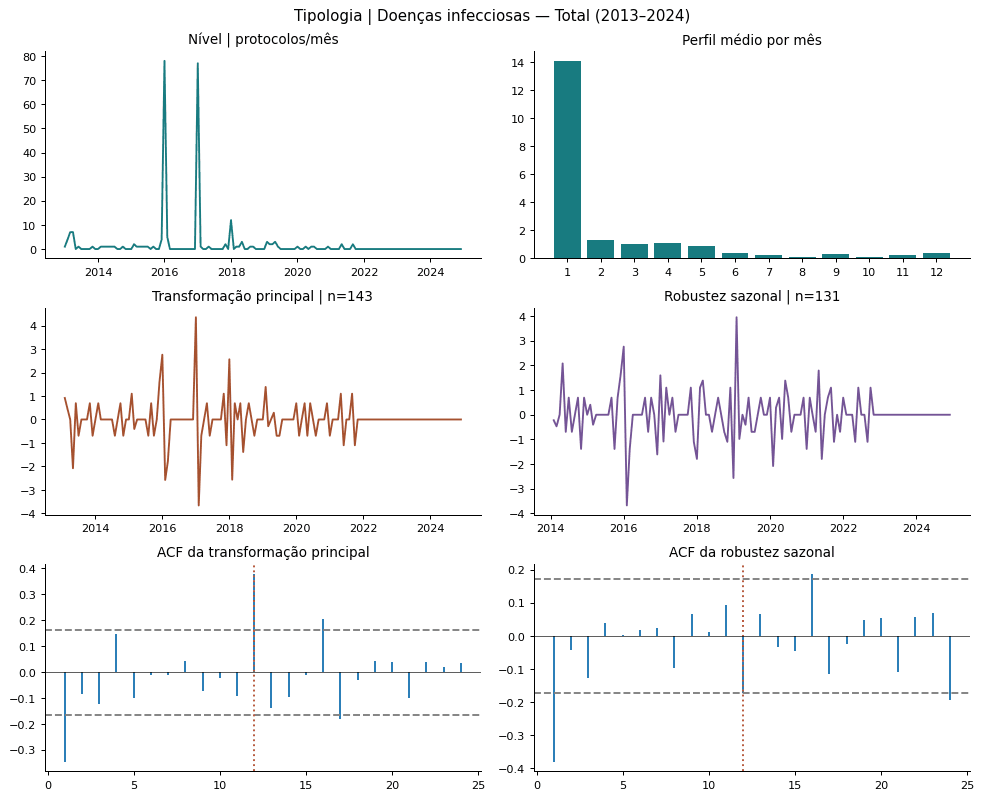

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
56,Nível,144,0,-1.783963,3.884524e-01,11,132,0.347307,0.099868,1,Interpolado,Inconclusiva: nenhum rejeita
57,Log,144,0,-1.530323,5.184612e-01,11,132,1.044032,0.010000,3,"p ≤ 0,01",Não estacionária: convergente
58,Primeira diferença,143,1,-10.734932,2.915402e-19,10,132,0.377559,0.086828,107,Interpolado,Estacionária: convergente
59,Diferença do log,143,1,-9.799784,6.038112e-17,10,132,0.143215,0.100000,38,"p ≥ 0,10",Estacionária: convergente
60,Diferença sazonal,132,12,-10.695062,3.642589e-19,0,131,0.083712,0.100000,0,"p ≥ 0,10",Estacionária: convergente
61,Diferença + sazonal,131,13,-7.699045,1.354701e-11,5,125,0.500000,0.041667,130,Interpolado,Conflitante: ambos rejeitam
62,Diferença do log + sazonal,131,13,-6.858308,1.626845e-09,8,122,0.089729,0.100000,19,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=6.038e-17, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=1.627e-09, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Doenças infecciosas — Pré-pandemia (até jan/2020)

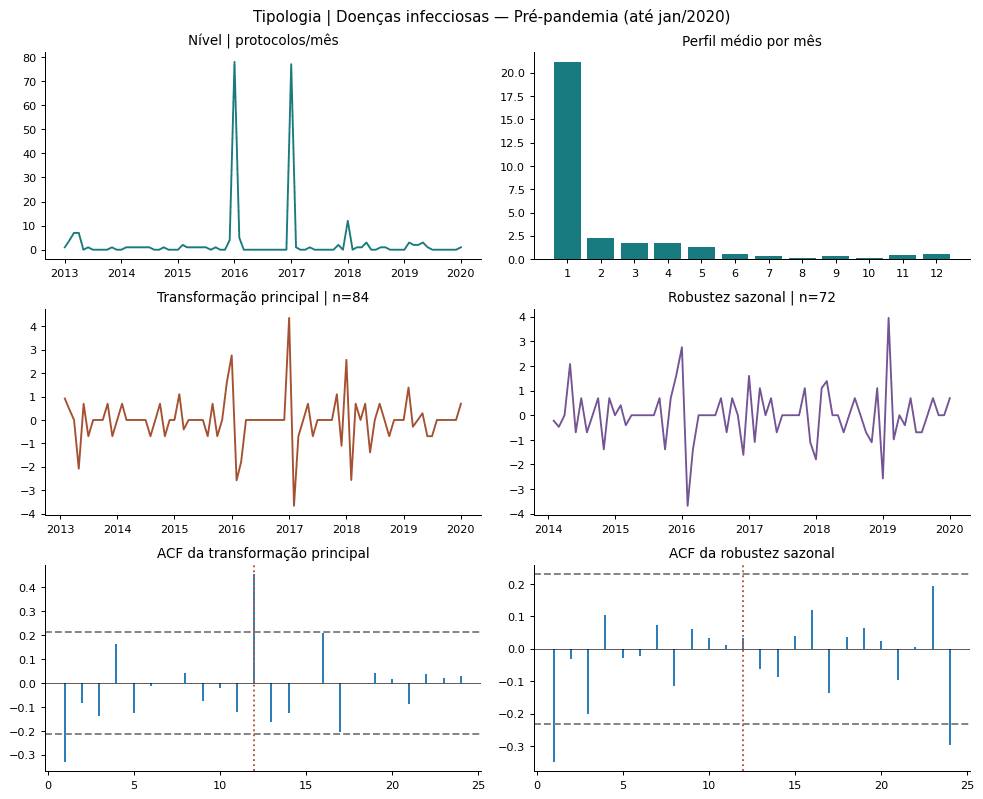

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
210,Nível,85,0,-1.527539,5.198467e-01,11,73,0.091754,0.100000,1,"p ≥ 0,10",Inconclusiva: nenhum rejeita
211,Log,85,0,-2.880775,4.762972e-02,12,72,0.059030,0.100000,2,"p ≥ 0,10",Estacionária: convergente
212,Primeira diferença,84,1,-7.667179,1.629446e-11,10,73,0.500000,0.041667,83,Interpolado,Conflitante: ambos rejeitam
213,Diferença do log,84,1,-7.637479,1.935119e-11,10,73,0.088060,0.100000,16,"p ≥ 0,10",Estacionária: convergente
214,Diferença sazonal,73,12,-7.877355,4.804246e-12,0,72,0.145927,0.100000,0,"p ≥ 0,10",Estacionária: convergente
215,Diferença + sazonal,72,13,-6.827223,1.934042e-09,3,68,0.500000,0.041667,71,Interpolado,Conflitante: ambos rejeitam
216,Diferença do log + sazonal,72,13,-7.939483,3.343684e-12,2,69,0.086860,0.100000,10,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.935e-11, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=3.344e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Enxurradas — Total (2013–2024)

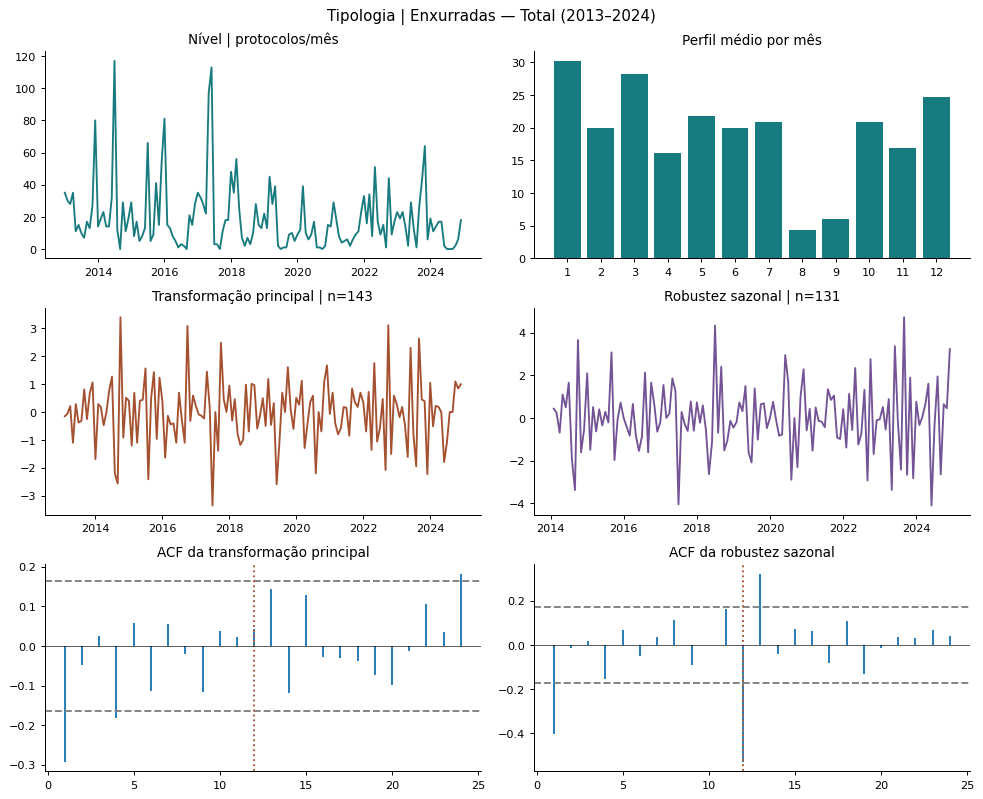

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
63,Nível,144,0,-8.923396,1.026595e-14,0,143,0.450802,0.055258,3,Interpolado,Estacionária: convergente
64,Log,144,0,-7.286065,1.457805e-10,0,143,0.360018,0.094389,5,Interpolado,Estacionária: convergente
65,Primeira diferença,143,1,-6.515073,1.076403e-08,10,132,0.072067,0.100000,19,"p ≥ 0,10",Estacionária: convergente
66,Diferença do log,143,1,-7.149845,3.162037e-10,11,131,0.039603,0.100000,8,"p ≥ 0,10",Estacionária: convergente
67,Diferença sazonal,132,12,-4.554643,1.564554e-04,12,119,0.040387,0.100000,3,"p ≥ 0,10",Estacionária: convergente
68,Diferença + sazonal,131,13,-5.696051,7.869715e-07,13,117,0.150497,0.100000,46,"p ≥ 0,10",Estacionária: convergente
69,Diferença do log + sazonal,131,13,-6.187954,6.222716e-08,13,117,0.082310,0.100000,17,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=3.162e-10, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=6.223e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Enxurradas — Pré-pandemia (até jan/2020)

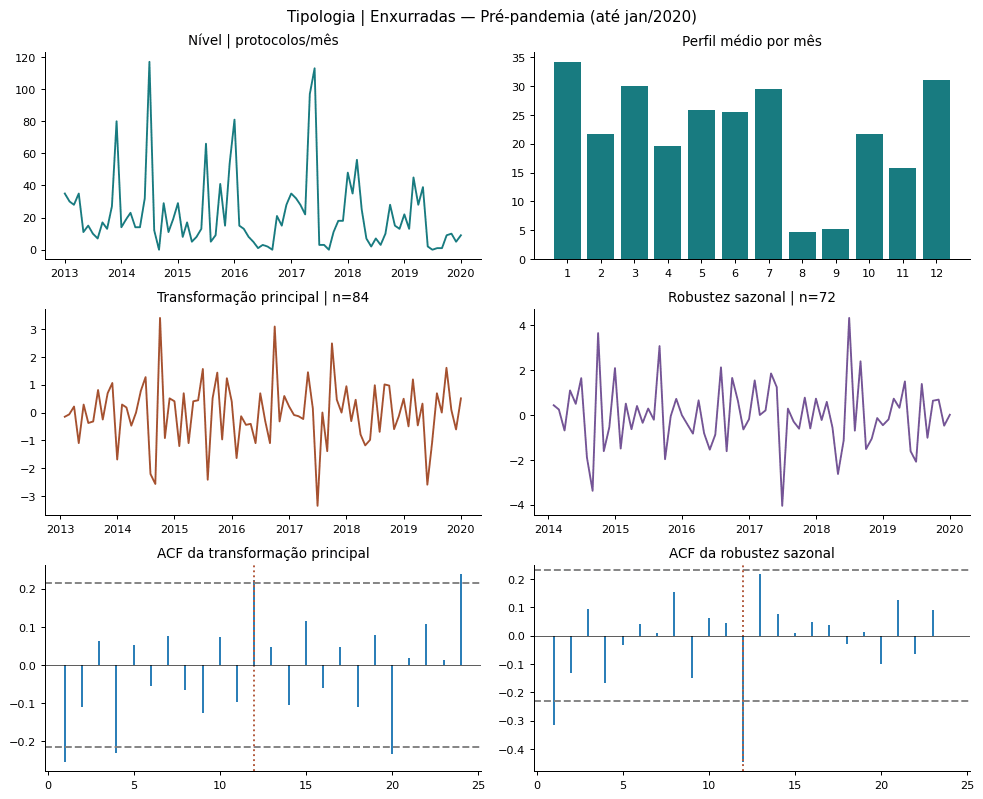

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
217,Nível,85,0,-6.865681,1.561379e-09,0,84,0.140697,0.100000,2,"p ≥ 0,10",Estacionária: convergente
218,Log,85,0,-5.627789,1.107146e-06,0,84,0.246771,0.100000,3,"p ≥ 0,10",Estacionária: convergente
219,Primeira diferença,84,1,-6.353732,2.573122e-08,5,78,0.257854,0.100000,47,"p ≥ 0,10",Estacionária: convergente
220,Diferença do log,84,1,-6.016834,1.526580e-07,10,73,0.103586,0.100000,11,"p ≥ 0,10",Estacionária: convergente
221,Diferença sazonal,73,12,-5.462841,2.496299e-06,1,71,0.061416,0.100000,2,"p ≥ 0,10",Estacionária: convergente
222,Diferença + sazonal,72,13,-6.305005,3.340188e-08,5,66,0.500000,0.041667,71,Interpolado,Conflitante: ambos rejeitam
223,Diferença do log + sazonal,72,13,-4.387937,3.117691e-04,12,59,0.206479,0.100000,22,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.527e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0003118, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Erosão — Total (2013–2024)

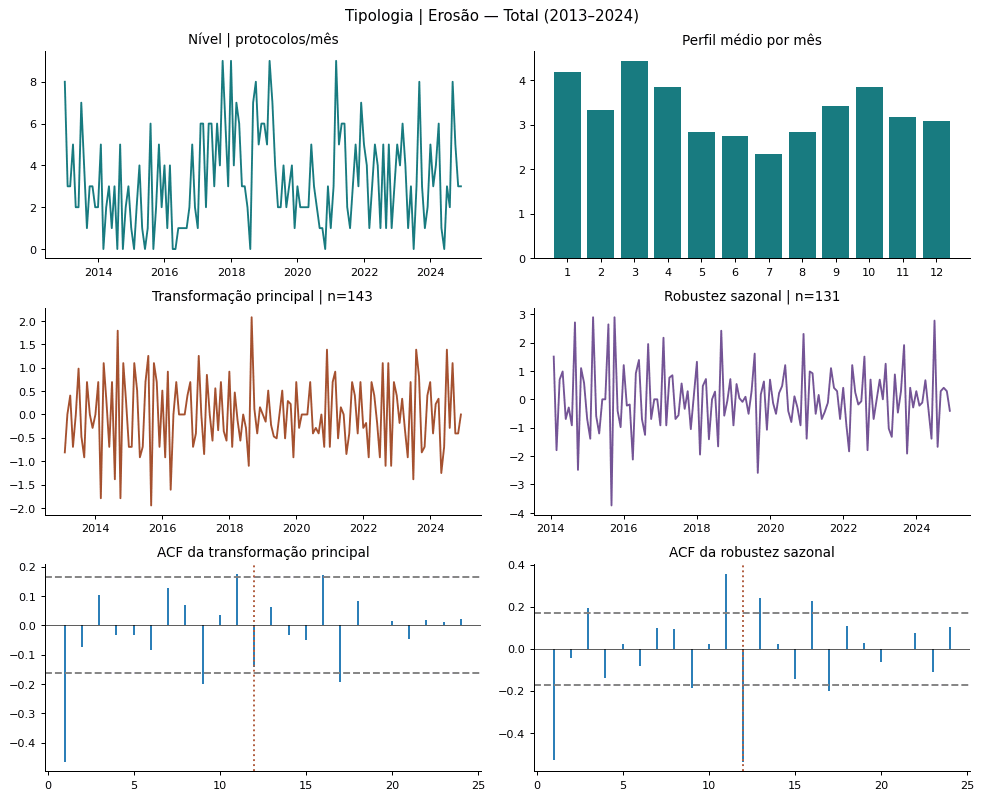

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
70,Nível,144,0,-4.643194,1.074520e-04,2,141,0.211175,0.1,6,"p ≥ 0,10",Estacionária: convergente
71,Log,144,0,-4.841178,4.533431e-05,2,141,0.265599,0.1,6,"p ≥ 0,10",Estacionária: convergente
72,Primeira diferença,143,1,-5.809987,4.424494e-07,9,133,0.055464,0.1,5,"p ≥ 0,10",Estacionária: convergente
73,Diferença do log,143,1,-6.348468,2.646820e-08,9,133,0.092355,0.1,16,"p ≥ 0,10",Estacionária: convergente
74,Diferença sazonal,132,12,-4.316941,4.151446e-04,11,120,0.098212,0.1,3,"p ≥ 0,10",Estacionária: convergente
75,Diferença + sazonal,131,13,-4.469767,2.229107e-04,13,117,0.138124,0.1,22,"p ≥ 0,10",Estacionária: convergente
76,Diferença do log + sazonal,131,13,-4.152351,7.925550e-04,13,117,0.119553,0.1,24,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=2.647e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0007926, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Erosão — Pré-pandemia (até jan/2020)

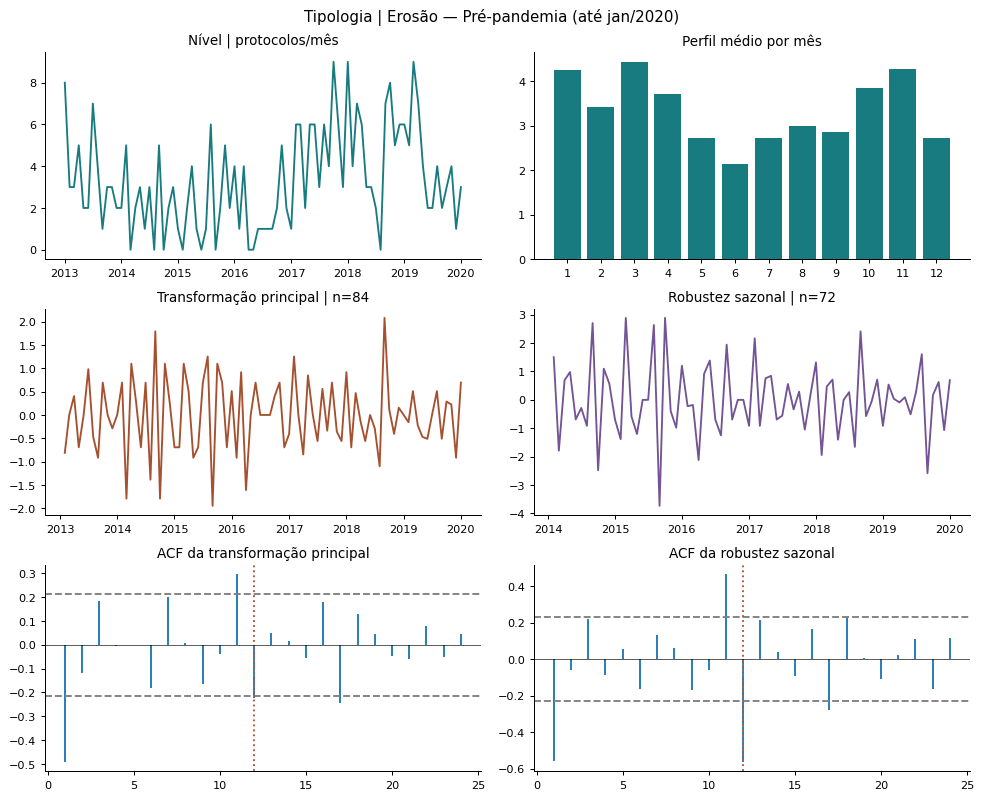

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
224,Nível,85,0,-1.319269,6.203112e-01,10,74,0.530156,0.034875,4,Interpolado,Não estacionária: convergente
225,Log,85,0,-2.879427,4.779316e-02,2,82,0.614822,0.021289,3,Interpolado,Conflitante: ambos rejeitam
226,Primeira diferença,84,1,-4.631663,1.128812e-04,9,74,0.193691,0.100000,17,"p ≥ 0,10",Estacionária: convergente
227,Diferença do log,84,1,-9.251210,1.490540e-15,2,81,0.188237,0.100000,17,"p ≥ 0,10",Estacionária: convergente
228,Diferença sazonal,73,12,-1.597758,4.847197e-01,12,60,0.319048,0.100000,2,"p ≥ 0,10",Inconclusiva: nenhum rejeita
229,Diferença + sazonal,72,13,-3.024175,3.269757e-02,11,60,0.251123,0.100000,13,"p ≥ 0,10",Estacionária: convergente
230,Diferença do log + sazonal,72,13,-2.200903,2.059179e-01,11,60,0.206490,0.100000,15,"p ≥ 0,10",Inconclusiva: nenhum rejeita


**Diferença do log:** Estacionária: convergente; ADF p=1.491e-15, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Inconclusiva: nenhum rejeita; ADF p=0.2059, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Há transformação sem convergência entre os testes. Mantemos a especificação histórica para comparação, mas a inferência correspondente é exploratória e não entra na classificação de diagnósticos favoráveis.

### Tipologia | Estiagem e Seca — Total (2013–2024)

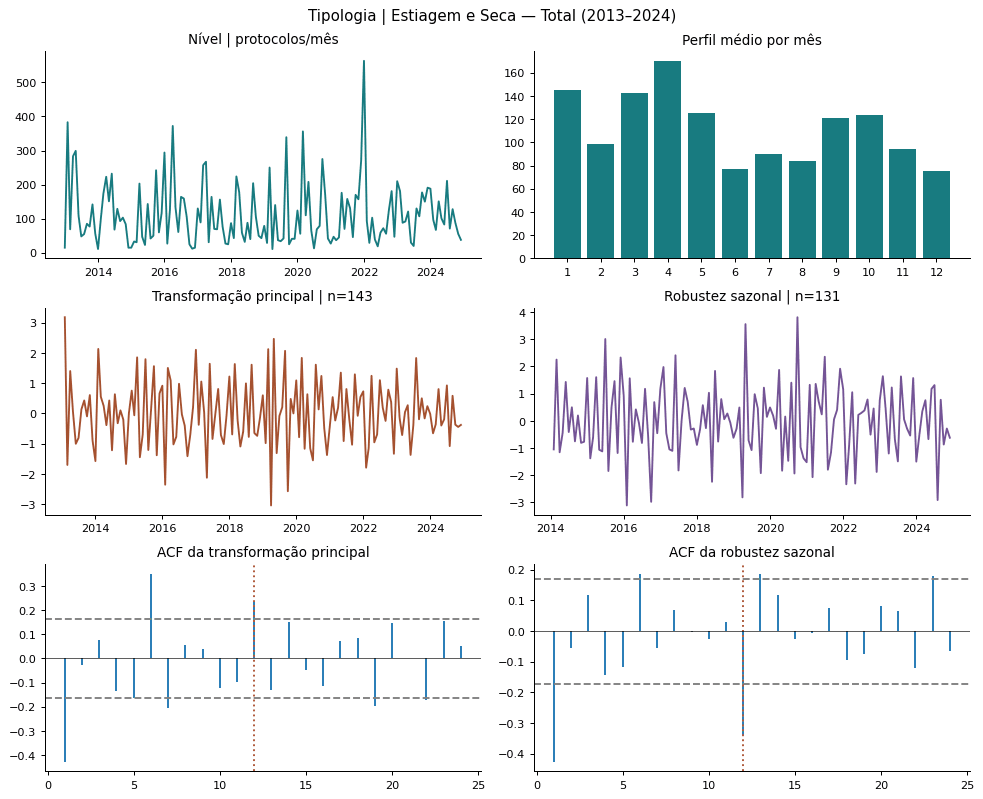

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
77,Nível,144,0,-5.703509,7.580357e-07,8,135,0.041156,0.1,3,"p ≥ 0,10",Estacionária: convergente
78,Log,144,0,-5.067392,1.629740e-05,6,137,0.090029,0.1,2,"p ≥ 0,10",Estacionária: convergente
79,Primeira diferença,143,1,-6.651514,5.106892e-09,12,130,0.043411,0.1,5,"p ≥ 0,10",Estacionária: convergente
80,Diferença do log,143,1,-6.253254,4.401362e-08,12,130,0.078055,0.1,9,"p ≥ 0,10",Estacionária: convergente
81,Diferença sazonal,132,12,-4.072920,1.073309e-03,13,118,0.045156,0.1,2,"p ≥ 0,10",Estacionária: convergente
82,Diferença + sazonal,131,13,-6.400574,2.000276e-08,13,117,0.142222,0.1,26,"p ≥ 0,10",Estacionária: convergente
83,Diferença do log + sazonal,131,13,-6.377300,2.267175e-08,13,117,0.265117,0.1,53,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=4.401e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=2.267e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Estiagem e Seca — Pré-pandemia (até jan/2020)

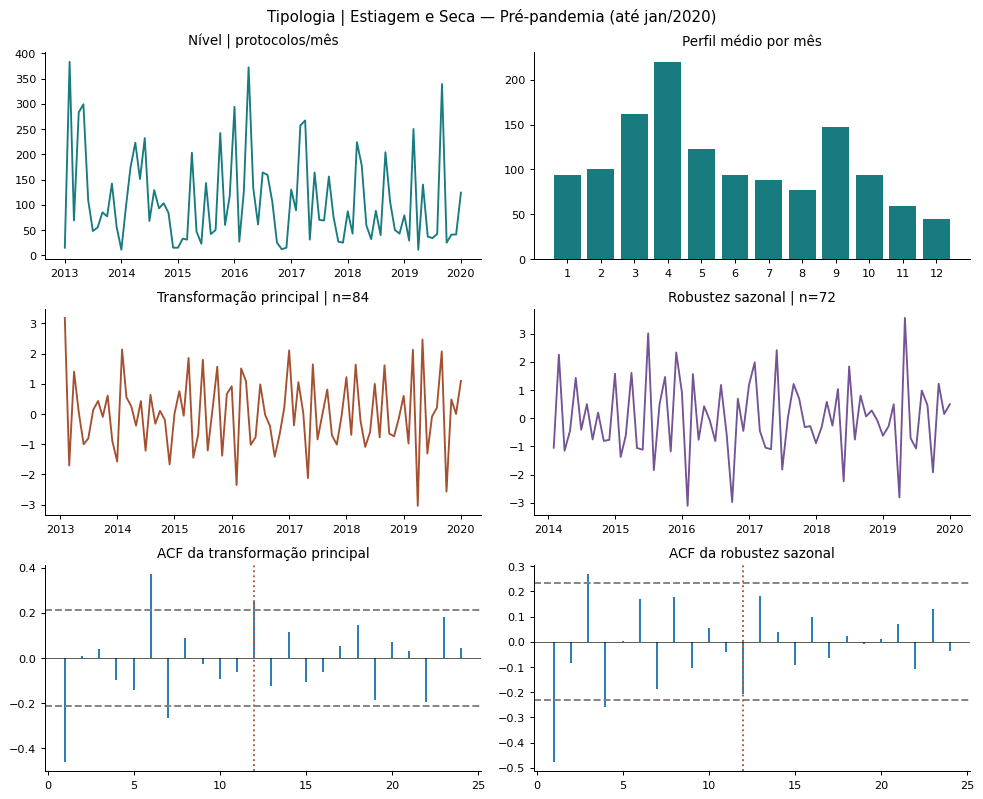

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
231,Nível,85,0,-2.144502,2.270006e-01,11,73,0.190578,0.1,0,"p ≥ 0,10",Inconclusiva: nenhum rejeita
232,Log,85,0,-3.910148,1.961419e-03,6,78,0.151566,0.1,1,"p ≥ 0,10",Estacionária: convergente
233,Primeira diferença,84,1,-6.513520,1.085531e-08,10,73,0.166265,0.1,26,"p ≥ 0,10",Estacionária: convergente
234,Diferença do log,84,1,-5.563454,1.523345e-06,10,73,0.151287,0.1,21,"p ≥ 0,10",Estacionária: convergente
235,Diferença sazonal,73,12,-3.408808,1.066225e-02,8,64,0.090976,0.1,1,"p ≥ 0,10",Estacionária: convergente
236,Diferença + sazonal,72,13,-14.622350,3.866884e-27,1,70,0.105577,0.1,13,"p ≥ 0,10",Estacionária: convergente
237,Diferença do log + sazonal,72,13,-4.182593,7.050581e-04,12,59,0.180153,0.1,22,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.523e-06, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0007051, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Granizo — Total (2013–2024)

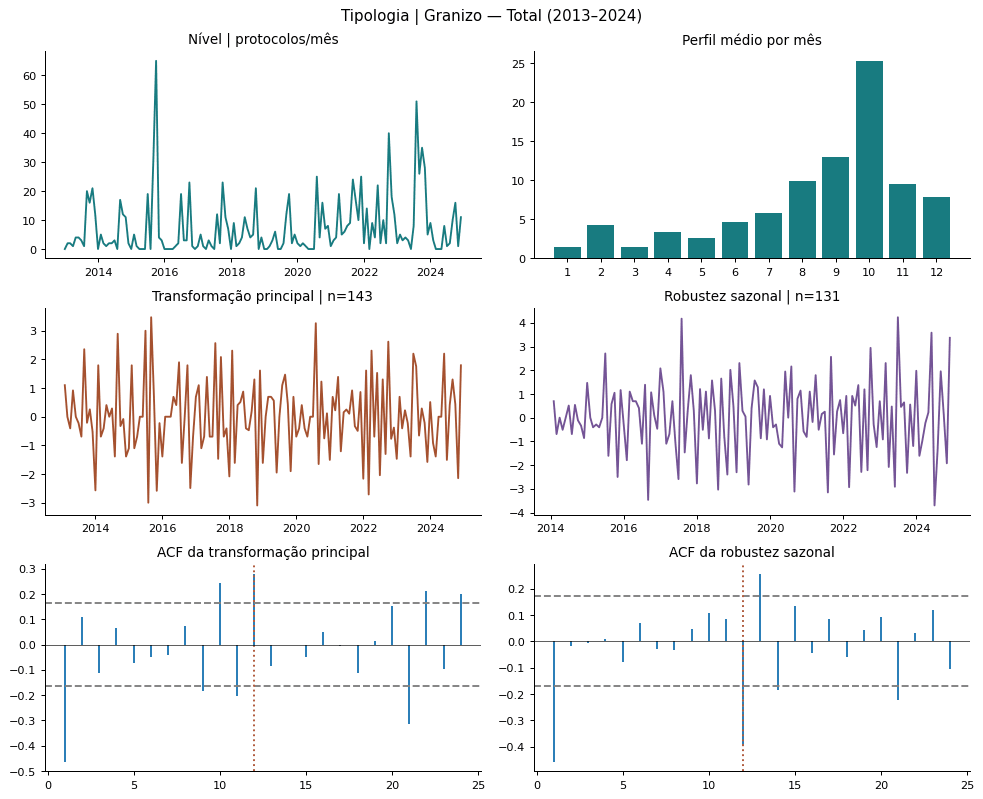

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
84,Nível,144,0,-2.233215,1.944120e-01,11,132,0.264622,0.100000,4,"p ≥ 0,10",Inconclusiva: nenhum rejeita
85,Log,144,0,-1.848626,3.566010e-01,11,132,0.425711,0.066073,5,Interpolado,Inconclusiva: nenhum rejeita
86,Primeira diferença,143,1,-8.559123,8.792825e-14,10,132,0.061253,0.100000,18,"p ≥ 0,10",Estacionária: convergente
87,Diferença do log,143,1,-8.909186,1.116282e-14,10,132,0.141893,0.100000,40,"p ≥ 0,10",Estacionária: convergente
88,Diferença sazonal,132,12,-5.281802,5.971499e-06,11,120,0.091844,0.100000,2,"p ≥ 0,10",Estacionária: convergente
89,Diferença + sazonal,131,13,-4.165026,7.547111e-04,13,117,0.137975,0.100000,36,"p ≥ 0,10",Estacionária: convergente
90,Diferença do log + sazonal,131,13,-4.241293,5.605129e-04,13,117,0.178127,0.100000,43,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.116e-14, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0005605, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Granizo — Pré-pandemia (até jan/2020)

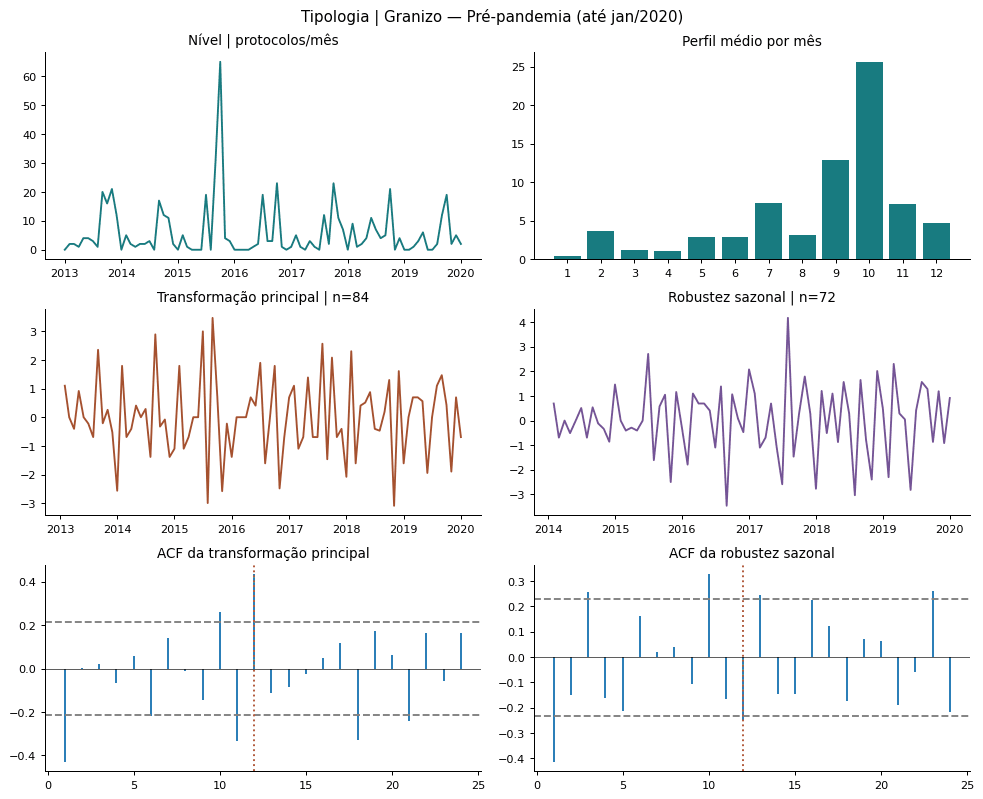

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
238,Nível,85,0,-1.885810,3.387657e-01,11,73,0.055264,0.100000,2,"p ≥ 0,10",Inconclusiva: nenhum rejeita
239,Log,85,0,-2.280125,1.784583e-01,11,73,0.031972,0.100000,3,"p ≥ 0,10",Inconclusiva: nenhum rejeita
240,Primeira diferença,84,1,-7.652222,1.776854e-11,10,73,0.500000,0.041667,83,Interpolado,Conflitante: ambos rejeitam
241,Diferença do log,84,1,-7.949263,3.158085e-12,10,73,0.127281,0.100000,16,"p ≥ 0,10",Estacionária: convergente
242,Diferença sazonal,73,12,-6.623112,5.968079e-09,0,72,0.058591,0.100000,2,"p ≥ 0,10",Estacionária: convergente
243,Diferença + sazonal,72,13,-10.338917,2.717462e-18,1,70,0.184044,0.100000,22,"p ≥ 0,10",Estacionária: convergente
244,Diferença do log + sazonal,72,13,-2.922518,4.279147e-02,9,62,0.192421,0.100000,23,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=3.158e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.04279, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Incêndio Florestal — Total (2013–2024)

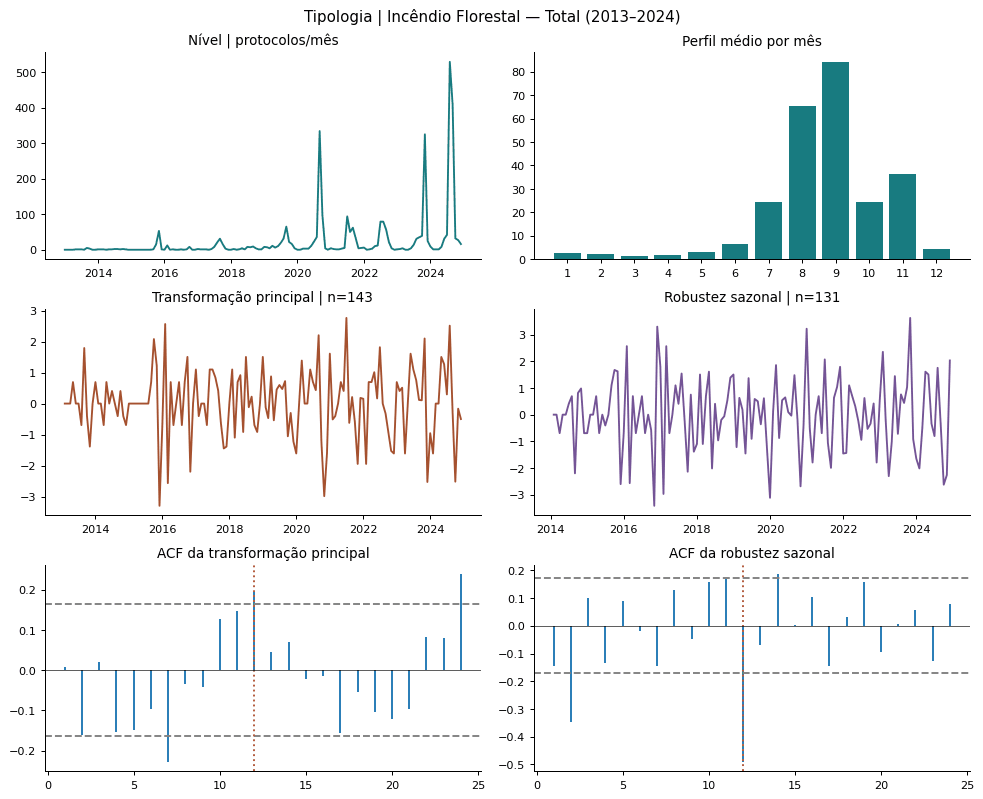

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
91,Nível,144,0,0.106251,9.664853e-01,11,132,0.814004,0.010000,4,"p ≤ 0,01",Não estacionária: convergente
92,Log,144,0,-0.980281,7.603882e-01,11,132,1.324331,0.010000,7,"p ≤ 0,01",Não estacionária: convergente
93,Primeira diferença,143,1,-6.782734,2.475765e-09,10,132,0.137383,0.100000,39,"p ≥ 0,10",Estacionária: convergente
94,Diferença do log,143,1,-7.885355,4.585332e-12,10,132,0.012575,0.100000,4,"p ≥ 0,10",Estacionária: convergente
95,Diferença sazonal,132,12,-2.099126,2.448660e-01,11,120,0.221052,0.100000,0,"p ≥ 0,10",Inconclusiva: nenhum rejeita
96,Diferença + sazonal,131,13,-3.970270,1.574441e-03,11,119,0.158863,0.100000,40,"p ≥ 0,10",Estacionária: convergente
97,Diferença do log + sazonal,131,13,-6.177537,6.574877e-08,13,117,0.421228,0.068005,115,Interpolado,Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=4.585e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=6.575e-08, KPSS Interpolado (valor tabelado 0.068), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Incêndio Florestal — Pré-pandemia (até jan/2020)

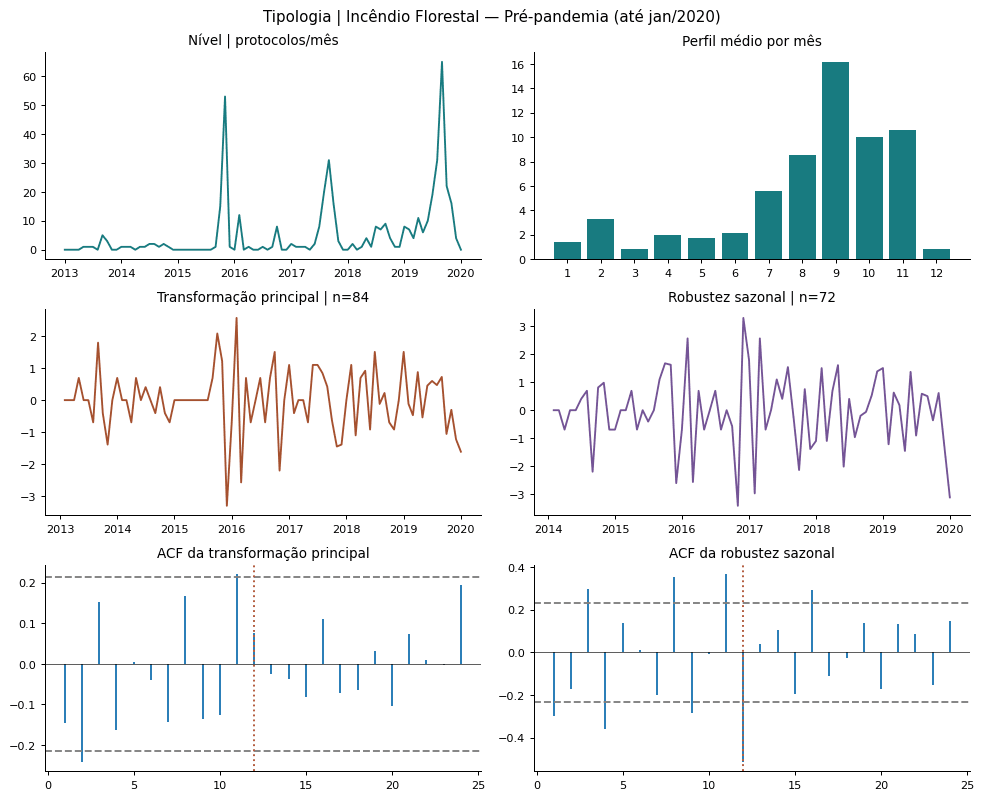

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
245,Nível,85,0,-5.087569,1.484869e-05,0,84,0.528982,0.035139,4,Interpolado,Conflitante: ambos rejeitam
246,Log,85,0,-4.338376,3.809373e-04,0,84,0.867375,0.010000,4,"p ≤ 0,01",Conflitante: ambos rejeitam
247,Primeira diferença,84,1,-6.355929,2.542954e-08,3,80,0.089980,0.100000,12,"p ≥ 0,10",Estacionária: convergente
248,Diferença do log,84,1,-5.219114,8.035538e-06,9,74,0.153813,0.100000,15,"p ≥ 0,10",Estacionária: convergente
249,Diferença sazonal,73,12,-5.313978,5.122169e-06,11,61,0.164212,0.100000,3,"p ≥ 0,10",Estacionária: convergente
250,Diferença + sazonal,72,13,-3.229707,1.832824e-02,12,59,0.210299,0.100000,32,"p ≥ 0,10",Estacionária: convergente
251,Diferença do log + sazonal,72,13,-3.702208,4.082207e-03,12,59,0.249515,0.100000,34,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=8.036e-06, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.004082, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Inundações — Total (2013–2024)

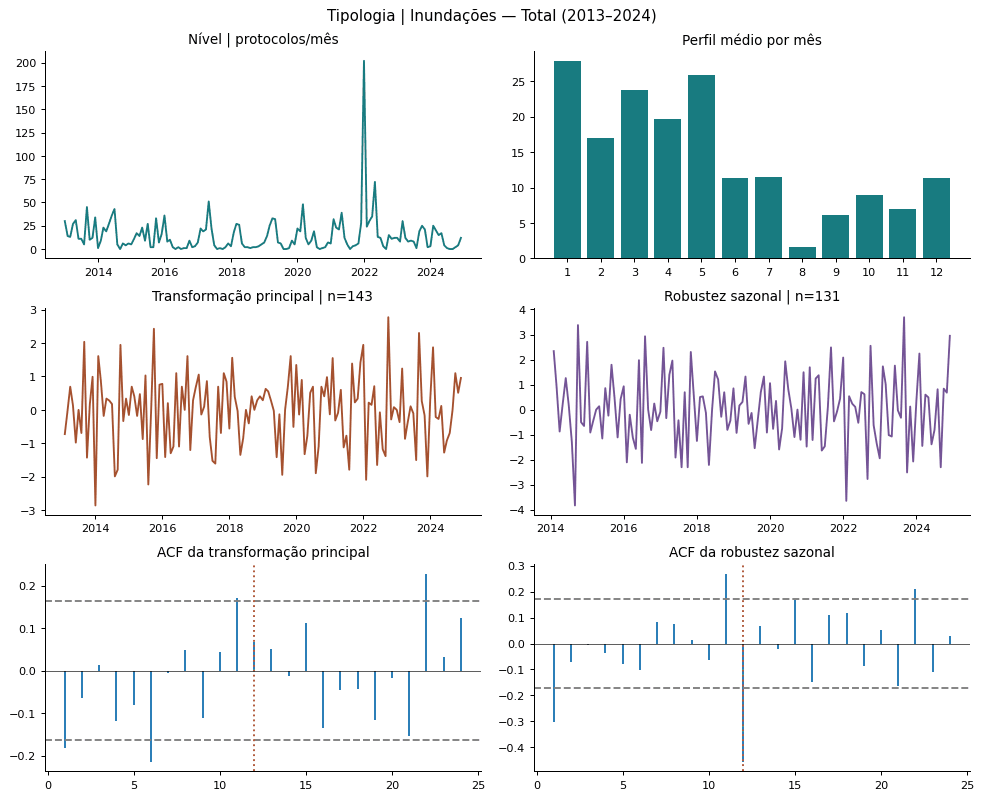

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
98,Nível,144,0,-9.434465,5.086214e-16,0,143,0.090048,0.1,4,"p ≥ 0,10",Estacionária: convergente
99,Log,144,0,-6.614741,6.248185e-09,5,138,0.112981,0.1,5,"p ≥ 0,10",Estacionária: convergente
100,Primeira diferença,143,1,-7.088246,4.479772e-10,9,133,0.253428,0.1,73,"p ≥ 0,10",Estacionária: convergente
101,Diferença do log,143,1,-8.271744,4.772761e-13,9,133,0.030831,0.1,6,"p ≥ 0,10",Estacionária: convergente
102,Diferença sazonal,132,12,-5.611261,1.202026e-06,11,120,0.077136,0.1,2,"p ≥ 0,10",Estacionária: convergente
103,Diferença + sazonal,131,13,-4.565410,1.495207e-04,13,117,0.168462,0.1,41,"p ≥ 0,10",Estacionária: convergente
104,Diferença do log + sazonal,131,13,-6.076134,1.120453e-07,13,117,0.079630,0.1,13,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=4.773e-13, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=1.12e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Inundações — Pré-pandemia (até jan/2020)

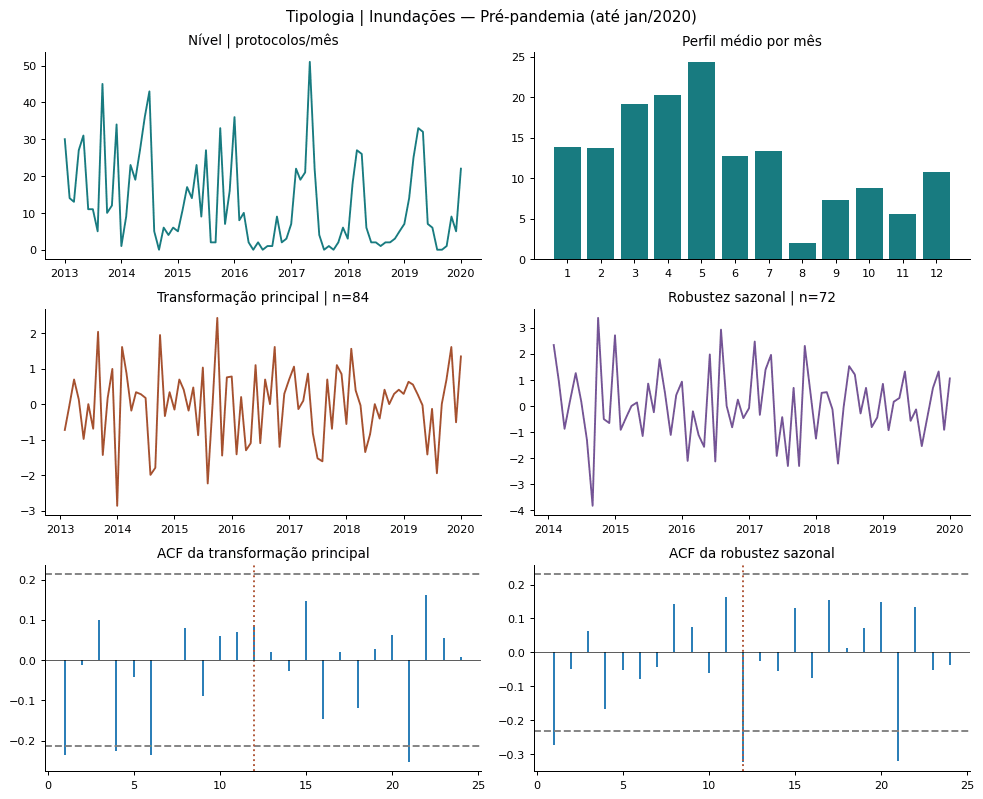

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
252,Nível,85,0,-4.916608,0.000032,3,81,0.349728,0.098824,3,Interpolado,Estacionária: convergente
253,Log,85,0,-5.339699,0.000005,3,81,0.365483,0.092033,4,Interpolado,Estacionária: convergente
254,Primeira diferença,84,1,-5.479915,0.000002,8,75,0.335959,0.100000,42,"p ≥ 0,10",Estacionária: convergente
255,Diferença do log,84,1,-5.111026,0.000013,10,73,0.053776,0.100000,5,"p ≥ 0,10",Estacionária: convergente
256,Diferença sazonal,73,12,-4.955140,0.000027,11,61,0.142760,0.100000,2,"p ≥ 0,10",Estacionária: convergente
257,Diferença + sazonal,72,13,-3.544941,0.006905,12,59,0.239457,0.100000,32,"p ≥ 0,10",Estacionária: convergente
258,Diferença do log + sazonal,72,13,-3.992639,0.001450,12,59,0.080991,0.100000,7,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.332e-05, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.00145, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Movimento de Massa — Total (2013–2024)

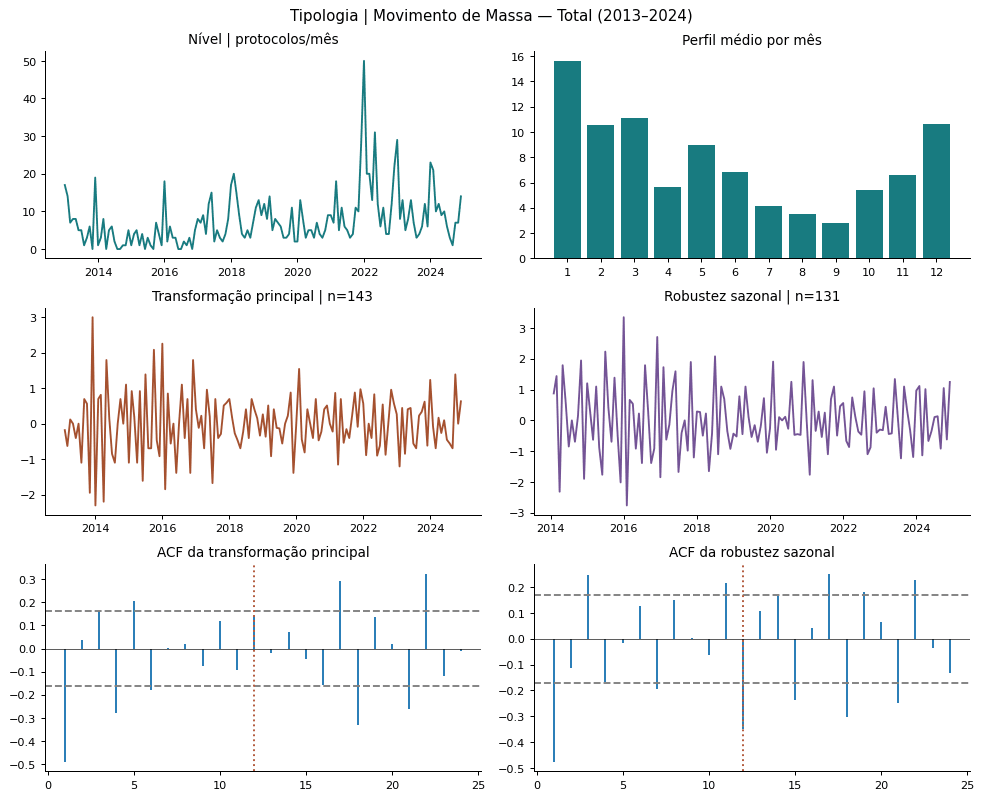

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
105,Nível,144,0,-1.947527,3.100434e-01,14,129,0.755998,0.01,6,"p ≤ 0,01",Não estacionária: convergente
106,Log,144,0,-1.417414,5.738996e-01,14,129,0.949194,0.01,7,"p ≤ 0,01",Não estacionária: convergente
107,Primeira diferença,143,1,-7.313593,1.245875e-10,10,132,0.129241,0.10,12,"p ≥ 0,10",Estacionária: convergente
108,Diferença do log,143,1,-6.842922,1.772334e-09,10,132,0.039738,0.10,3,"p ≥ 0,10",Estacionária: convergente
109,Diferença sazonal,132,12,-4.197776,6.646341e-04,11,120,0.115513,0.10,4,"p ≥ 0,10",Estacionária: convergente
110,Diferença + sazonal,131,13,-3.501122,7.958326e-03,11,119,0.146427,0.10,29,"p ≥ 0,10",Estacionária: convergente
111,Diferença do log + sazonal,131,13,-3.955449,1.662626e-03,12,118,0.145168,0.10,23,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.772e-09, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.001663, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Movimento de Massa — Pré-pandemia (até jan/2020)

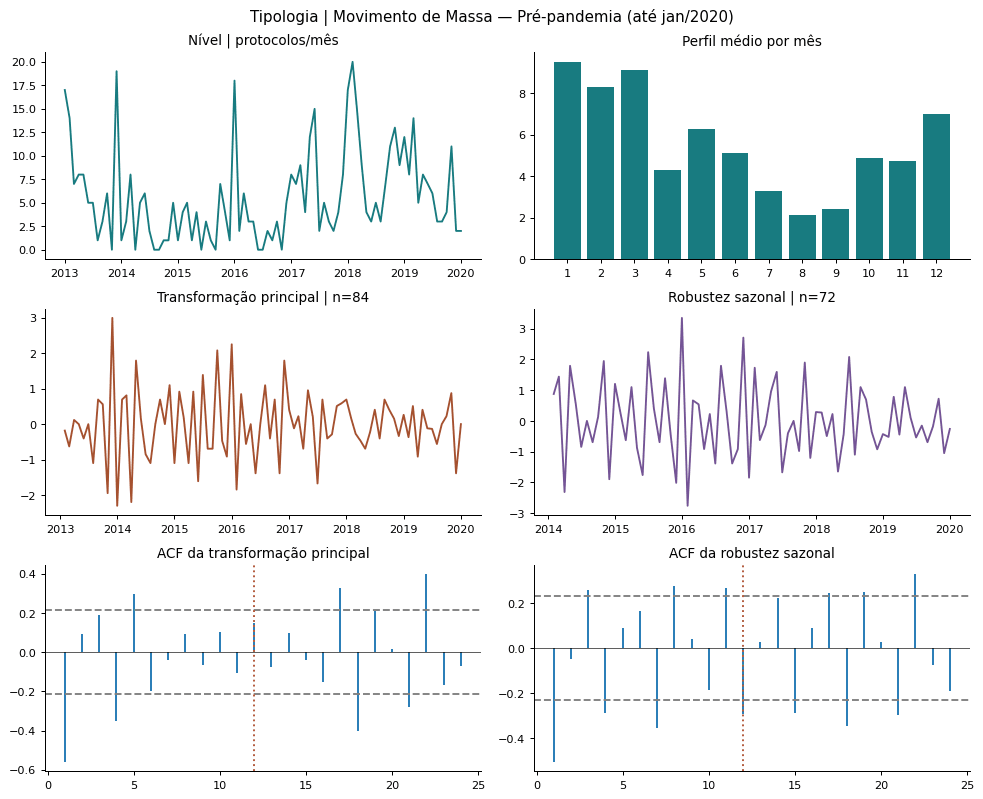

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
259,Nível,85,0,-4.085681,1.022676e-03,3,81,0.306277,0.100000,4,"p ≥ 0,10",Estacionária: convergente
260,Log,85,0,-3.445626,9.498405e-03,3,81,0.449922,0.055637,4,Interpolado,Estacionária: convergente
261,Primeira diferença,84,1,-6.474992,1.338014e-08,6,77,0.176743,0.100000,11,"p ≥ 0,10",Estacionária: convergente
262,Diferença do log,84,1,-5.924955,2.456132e-07,7,76,0.186058,0.100000,26,"p ≥ 0,10",Estacionária: convergente
263,Diferença sazonal,73,12,-1.550664,5.083165e-01,7,65,0.294770,0.100000,3,"p ≥ 0,10",Inconclusiva: nenhum rejeita
264,Diferença + sazonal,72,13,-7.006377,7.104600e-10,6,65,0.430616,0.063959,18,Interpolado,Estacionária: convergente
265,Diferença do log + sazonal,72,13,-11.591790,2.780558e-21,1,70,0.363753,0.092779,23,Interpolado,Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=2.456e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=2.781e-21, KPSS Interpolado (valor tabelado 0.093), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Onda de Calor e Baixa Umidade — Total (2013–2024)

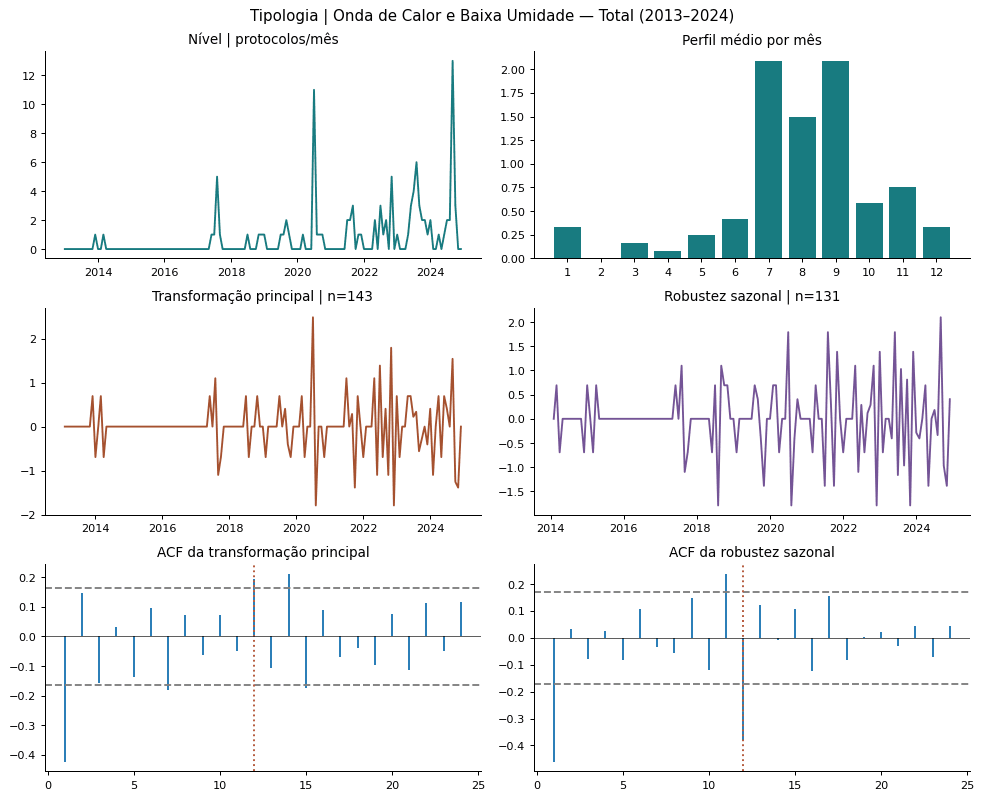

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
112,Nível,144,0,-0.407268,9.088781e-01,13,130,1.187007,0.010000,4,"p ≤ 0,01",Não estacionária: convergente
113,Log,144,0,-0.736417,8.370898e-01,13,130,1.310405,0.010000,6,"p ≤ 0,01",Não estacionária: convergente
114,Primeira diferença,143,1,-8.181888,8.089737e-13,12,130,0.160243,0.100000,43,"p ≥ 0,10",Estacionária: convergente
115,Diferença do log,143,1,-7.062065,5.192828e-10,12,130,0.116435,0.100000,26,"p ≥ 0,10",Estacionária: convergente
116,Diferença sazonal,132,12,-4.095207,9.863444e-04,12,119,0.086796,0.100000,3,"p ≥ 0,10",Estacionária: convergente
117,Diferença + sazonal,131,13,-5.258906,6.657453e-06,13,117,0.500000,0.041667,130,Interpolado,Conflitante: ambos rejeitam
118,Diferença do log + sazonal,131,13,-4.804298,5.336562e-05,13,117,0.112411,0.100000,18,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=5.193e-10, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=5.337e-05, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Onda de Calor e Baixa Umidade — Pré-pandemia (até jan/2020)

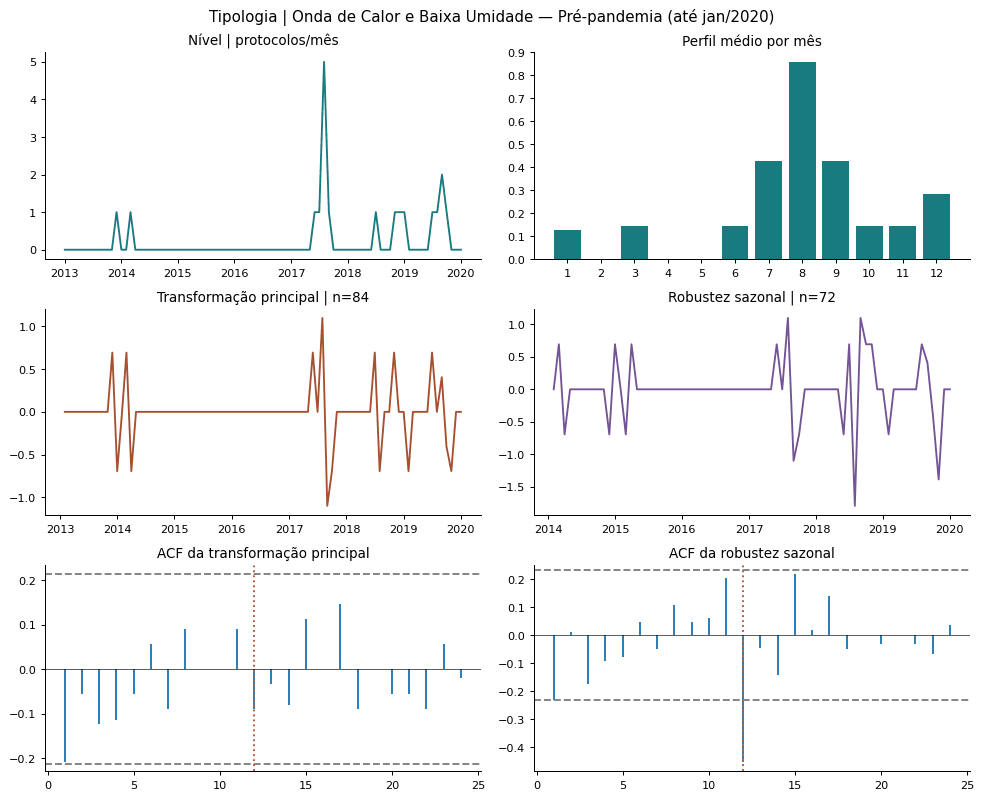

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
266,Nível,85,0,-6.116952,9.046398e-08,0,84,0.373211,0.088702,3,Interpolado,Estacionária: convergente
267,Log,85,0,-5.156251,1.079236e-05,0,84,0.456574,0.052770,4,Interpolado,Estacionária: convergente
268,Primeira diferença,84,1,-6.137450,8.122256e-08,4,79,0.065959,0.100000,9,"p ≥ 0,10",Estacionária: convergente
269,Diferença do log,84,1,-5.668061,9.055080e-07,6,77,0.046008,0.100000,6,"p ≥ 0,10",Estacionária: convergente
270,Diferença sazonal,73,12,-4.625906,1.156887e-04,11,61,0.055193,0.100000,3,"p ≥ 0,10",Estacionária: convergente
271,Diferença + sazonal,72,13,-3.166893,2.198279e-02,12,59,0.064862,0.100000,6,"p ≥ 0,10",Estacionária: convergente
272,Diferença do log + sazonal,72,13,-3.783014,3.085968e-03,12,59,0.044779,0.100000,3,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=9.055e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.003086, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Onda de Frio — Total (2013–2024)

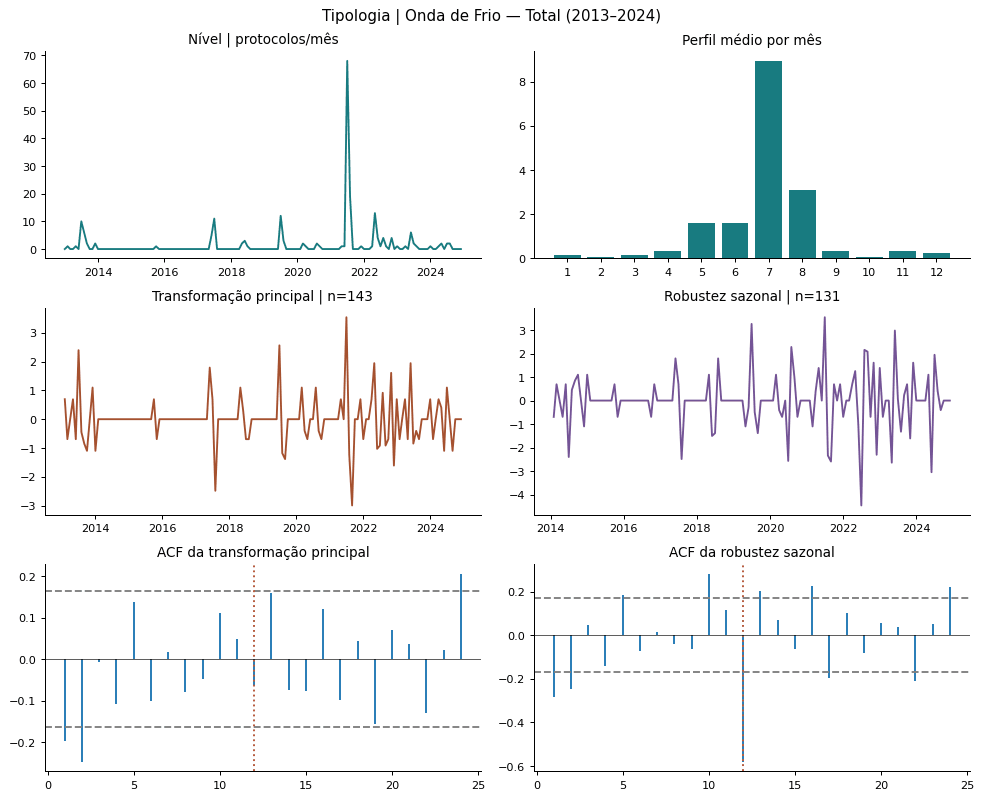

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
119,Nível,144,0,-9.226454,1.723961e-15,0,143,0.210896,0.100000,1,"p ≥ 0,10",Estacionária: convergente
120,Log,144,0,-7.416111,6.928607e-11,1,142,0.393984,0.079748,3,Interpolado,Estacionária: convergente
121,Primeira diferença,143,1,-7.524440,3.716754e-11,8,134,0.479188,0.046354,136,Interpolado,Conflitante: ambos rejeitam
122,Diferença do log,143,1,-7.510482,4.027914e-11,11,131,0.141631,0.100000,34,"p ≥ 0,10",Estacionária: convergente
123,Diferença sazonal,132,12,-4.189380,6.867125e-04,12,119,0.066191,0.100000,0,"p ≥ 0,10",Estacionária: convergente
124,Diferença + sazonal,131,13,-4.118654,9.020005e-04,11,119,0.167363,0.100000,43,"p ≥ 0,10",Estacionária: convergente
125,Diferença do log + sazonal,131,13,-4.420534,2.729558e-04,13,117,0.237517,0.100000,47,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=4.028e-11, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.000273, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Onda de Frio — Pré-pandemia (até jan/2020)

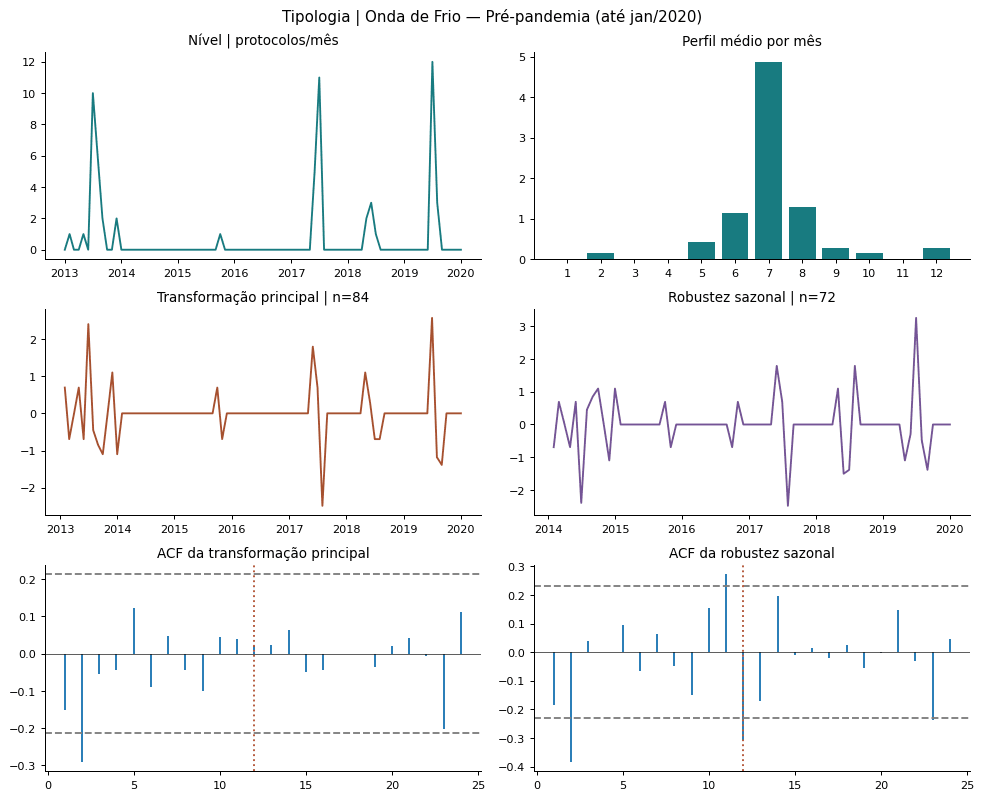

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
273,Nível,85,0,-6.574962,7.766876e-09,0,84,0.087293,0.1,2,"p ≥ 0,10",Estacionária: convergente
274,Log,85,0,-5.882365,3.057133e-07,1,83,0.101372,0.1,3,"p ≥ 0,10",Estacionária: convergente
275,Primeira diferença,84,1,-7.214043,2.196712e-10,3,80,0.208333,0.1,34,"p ≥ 0,10",Estacionária: convergente
276,Diferença do log,84,1,-7.205815,2.301852e-10,3,80,0.166667,0.1,27,"p ≥ 0,10",Estacionária: convergente
277,Diferença sazonal,73,12,-4.279186,4.825593e-04,11,61,0.278179,0.1,1,"p ≥ 0,10",Estacionária: convergente
278,Diferença + sazonal,72,13,-2.692567,7.533331e-02,11,60,0.275253,0.1,39,"p ≥ 0,10",Inconclusiva: nenhum rejeita
279,Diferença do log + sazonal,72,13,-2.638363,8.532469e-02,11,60,0.194444,0.1,27,"p ≥ 0,10",Inconclusiva: nenhum rejeita


**Diferença do log:** Estacionária: convergente; ADF p=2.302e-10, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Inconclusiva: nenhum rejeita; ADF p=0.08532, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Há transformação sem convergência entre os testes. Mantemos a especificação histórica para comparação, mas a inferência correspondente é exploratória e não entra na classificação de diagnósticos favoráveis.

### Tipologia | Outros — Total (2013–2024)

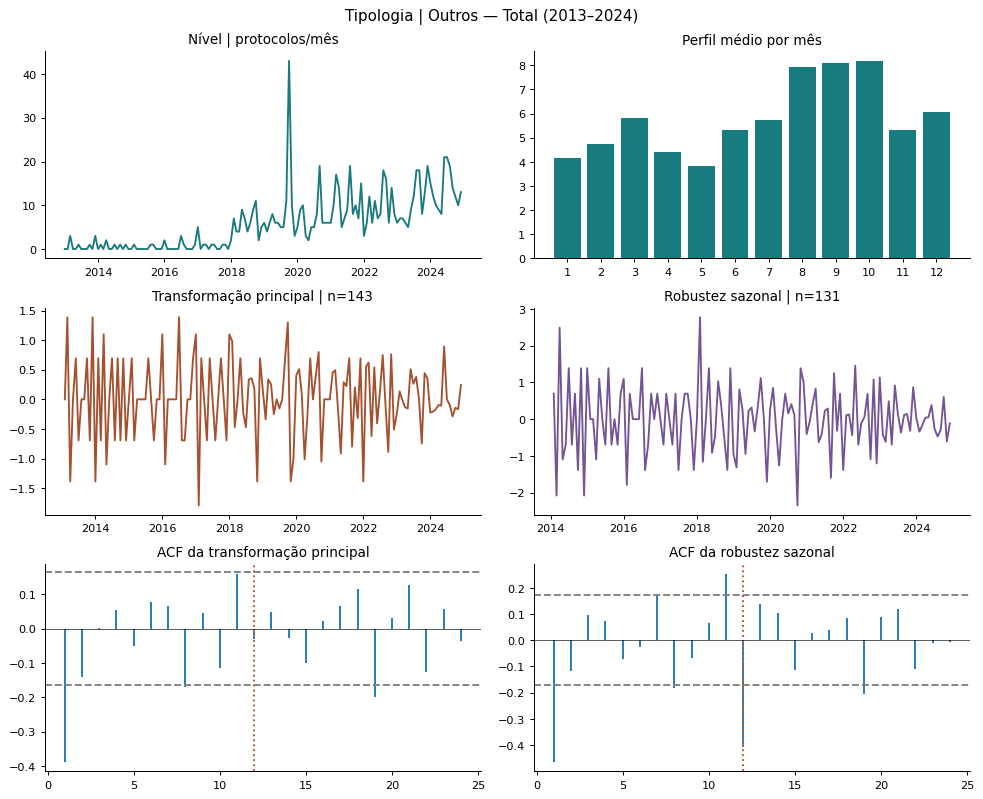

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
126,Nível,144,0,-0.172380,9.417347e-01,12,131,1.648290,0.01,7,"p ≤ 0,01",Não estacionária: convergente
127,Log,144,0,-0.788156,8.225764e-01,10,133,1.535873,0.01,8,"p ≤ 0,01",Não estacionária: convergente
128,Primeira diferença,143,1,-6.689121,4.152703e-09,11,131,0.129377,0.10,37,"p ≥ 0,10",Estacionária: convergente
129,Diferença do log,143,1,-5.704109,7.557520e-07,9,133,0.171809,0.10,53,"p ≥ 0,10",Estacionária: convergente
130,Diferença sazonal,132,12,-3.455743,9.199177e-03,12,119,0.139205,0.10,1,"p ≥ 0,10",Estacionária: convergente
131,Diferença + sazonal,131,13,-4.872755,3.939264e-05,13,117,0.216365,0.10,47,"p ≥ 0,10",Estacionária: convergente
132,Diferença do log + sazonal,131,13,-4.911948,3.305416e-05,11,119,0.111036,0.10,24,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=7.558e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=3.305e-05, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Outros — Pré-pandemia (até jan/2020)

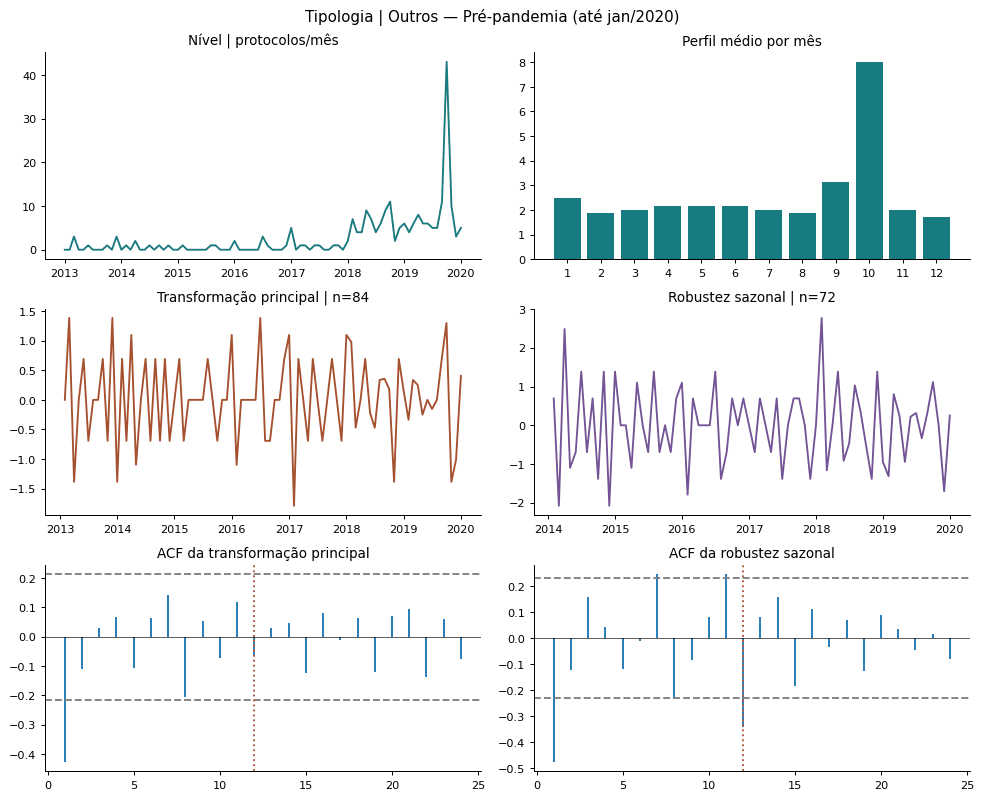

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
280,Nível,85,0,2.853315,1.000000e+00,12,72,1.027769,0.01,4,"p ≤ 0,01",Não estacionária: convergente
281,Log,85,0,-0.893341,7.901574e-01,3,81,1.098865,0.01,5,"p ≤ 0,01",Não estacionária: convergente
282,Primeira diferença,84,1,-3.577745,6.201036e-03,11,72,0.230472,0.10,41,"p ≥ 0,10",Estacionária: convergente
283,Diferença do log,84,1,-6.483879,1.275075e-08,4,79,0.169313,0.10,34,"p ≥ 0,10",Estacionária: convergente
284,Diferença sazonal,73,12,-0.130895,9.462730e-01,12,60,0.751190,0.01,2,"p ≤ 0,01",Não estacionária: convergente
285,Diferença + sazonal,72,13,-5.405967,3.290822e-06,12,59,0.171167,0.10,22,"p ≥ 0,10",Estacionária: convergente
286,Diferença do log + sazonal,72,13,-4.135915,8.442816e-04,9,62,0.153553,0.10,17,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=1.275e-08, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=0.0008443, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Rompimento/Colapso de barragens — Total (2013–2024)

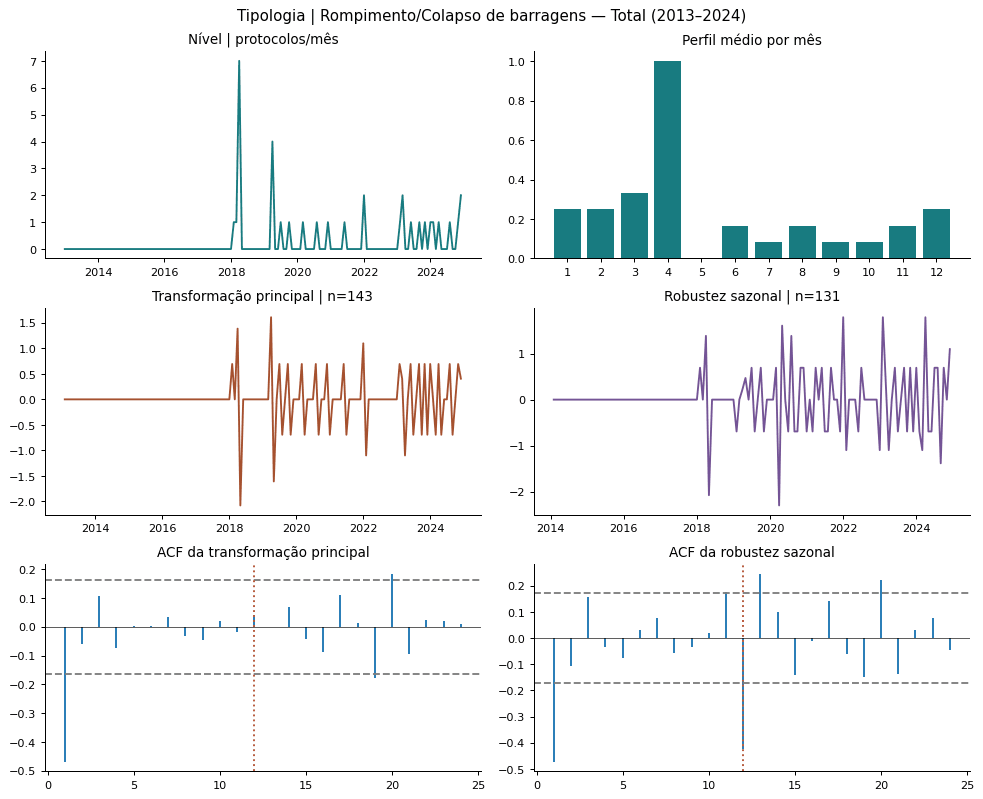

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
133,Nível,144,0,-10.923226,1.025447e-19,0,143,0.500850,0.041475,3,Interpolado,Conflitante: ambos rejeitam
134,Log,144,0,-10.374940,2.214149e-18,0,143,0.952771,0.010000,4,"p ≤ 0,01",Conflitante: ambos rejeitam
135,Primeira diferença,143,1,-7.580267,2.693515e-11,10,132,0.157040,0.100000,25,"p ≥ 0,10",Estacionária: convergente
136,Diferença do log,143,1,-6.536398,9.584822e-09,12,130,0.136781,0.100000,13,"p ≥ 0,10",Estacionária: convergente
137,Diferença sazonal,132,12,-11.006173,6.495741e-20,0,131,0.057267,0.100000,0,"p ≥ 0,10",Estacionária: convergente
138,Diferença + sazonal,131,13,-5.238331,7.338615e-06,12,118,0.299584,0.100000,69,"p ≥ 0,10",Estacionária: convergente
139,Diferença do log + sazonal,131,13,-5.628454,1.103485e-06,13,117,0.178208,0.100000,24,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=9.585e-09, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=1.103e-06, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Rompimento/Colapso de barragens — Pré-pandemia (até jan/2020)

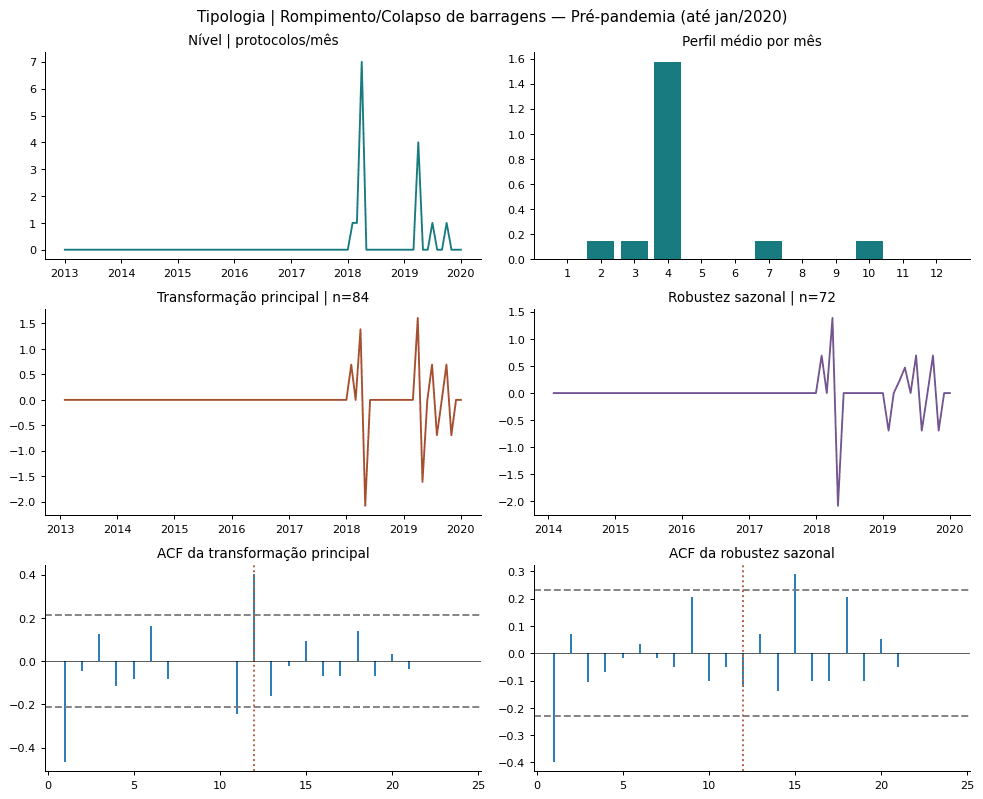

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
287,Nível,85,0,-8.355749,2.912437e-13,0,84,0.420952,0.068124,2,Interpolado,Estacionária: convergente
288,Log,85,0,-1.426188,5.696590e-01,12,72,0.509777,0.039465,3,Interpolado,Não estacionária: convergente
289,Primeira diferença,84,1,-6.548761,8.960481e-09,10,73,0.285714,0.100000,47,"p ≥ 0,10",Estacionária: convergente
290,Diferença do log,84,1,-7.041180,5.841315e-10,10,73,0.404762,0.075103,67,Interpolado,Estacionária: convergente
291,Diferença sazonal,73,12,-6.966587,8.882696e-10,0,72,0.076380,0.100000,3,"p ≥ 0,10",Estacionária: convergente
292,Diferença + sazonal,72,13,-6.393295,2.080239e-08,3,68,0.062500,0.100000,8,"p ≥ 0,10",Estacionária: convergente
293,Diferença do log + sazonal,72,13,-12.654948,1.343044e-23,0,71,0.045658,0.100000,6,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=5.841e-10, KPSS Interpolado (valor tabelado 0.075), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=1.343e-23, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Tornado — Total (2013–2024)

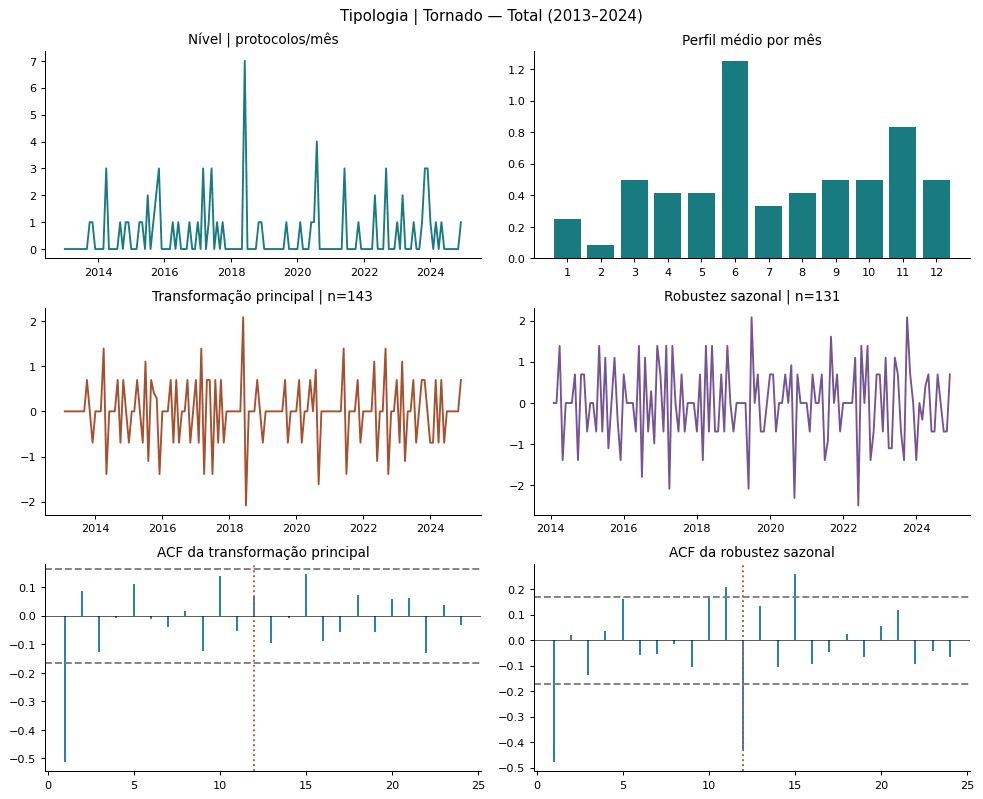

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
140,Nível,144,0,-11.935461,4.673896e-22,0,143,0.057604,0.1,5,"p ≥ 0,10",Estacionária: convergente
141,Log,144,0,-11.850026,7.245303e-22,0,143,0.072193,0.1,4,"p ≥ 0,10",Estacionária: convergente
142,Primeira diferença,143,1,-6.411573,1.885150e-08,13,129,0.160579,0.1,46,"p ≥ 0,10",Estacionária: convergente
143,Diferença do log,143,1,-5.853708,3.540253e-07,13,129,0.138233,0.1,35,"p ≥ 0,10",Estacionária: convergente
144,Diferença sazonal,132,12,-5.678251,8.604627e-07,11,120,0.067686,0.1,1,"p ≥ 0,10",Estacionária: convergente
145,Diferença + sazonal,131,13,-5.653813,9.723702e-07,13,117,0.154447,0.1,25,"p ≥ 0,10",Estacionária: convergente
146,Diferença do log + sazonal,131,13,-5.362067,4.067305e-06,13,117,0.117402,0.1,27,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=3.54e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=4.067e-06, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Tornado — Pré-pandemia (até jan/2020)

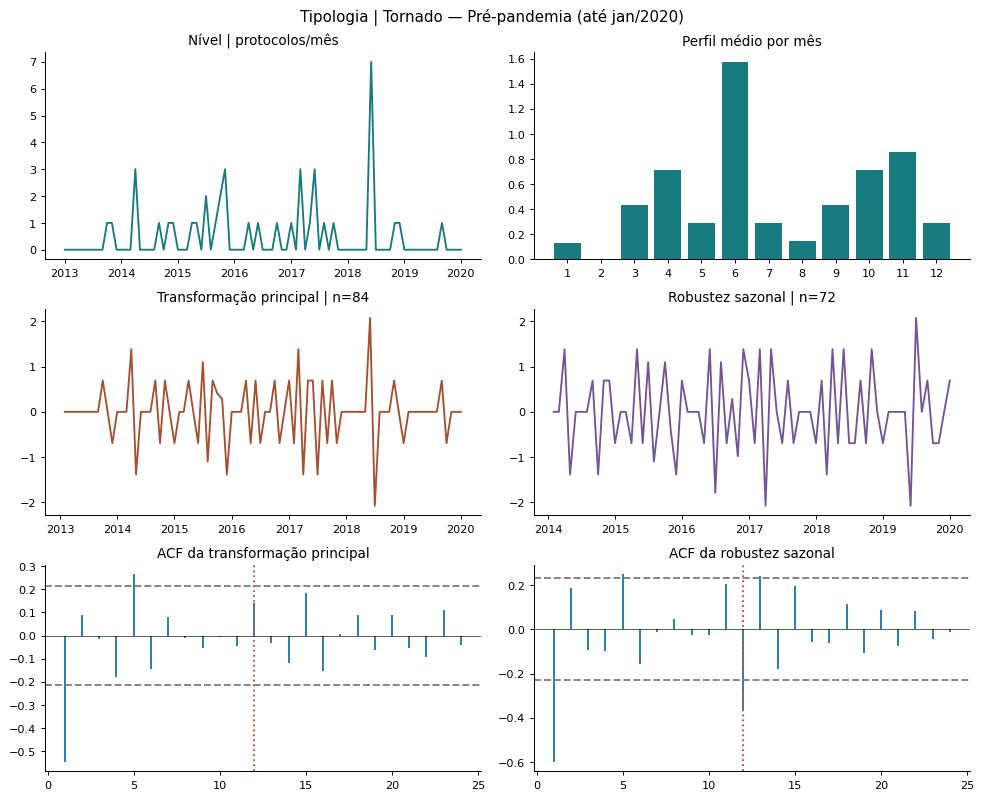

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
294,Nível,85,0,-9.568711,2.319271e-16,0,84,0.112179,0.100000,1,"p ≥ 0,10",Estacionária: convergente
295,Log,85,0,-9.461507,4.341297e-16,0,84,0.170634,0.100000,1,"p ≥ 0,10",Estacionária: convergente
296,Primeira diferença,84,1,-8.429986,1.881514e-13,3,80,0.500000,0.041667,83,Interpolado,Conflitante: ambos rejeitam
297,Diferença do log,84,1,-9.135619,2.941278e-15,3,80,0.157797,0.100000,21,"p ≥ 0,10",Estacionária: convergente
298,Diferença sazonal,73,12,-4.271524,4.974465e-04,11,61,0.236072,0.100000,1,"p ≥ 0,10",Estacionária: convergente
299,Diferença + sazonal,72,13,-3.385118,1.147680e-02,12,59,0.060644,0.100000,11,"p ≥ 0,10",Estacionária: convergente
300,Diferença do log + sazonal,72,13,-8.084819,1.429212e-12,3,68,0.057980,0.100000,8,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=2.941e-15, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=1.429e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Vendavais e Ciclones — Total (2013–2024)

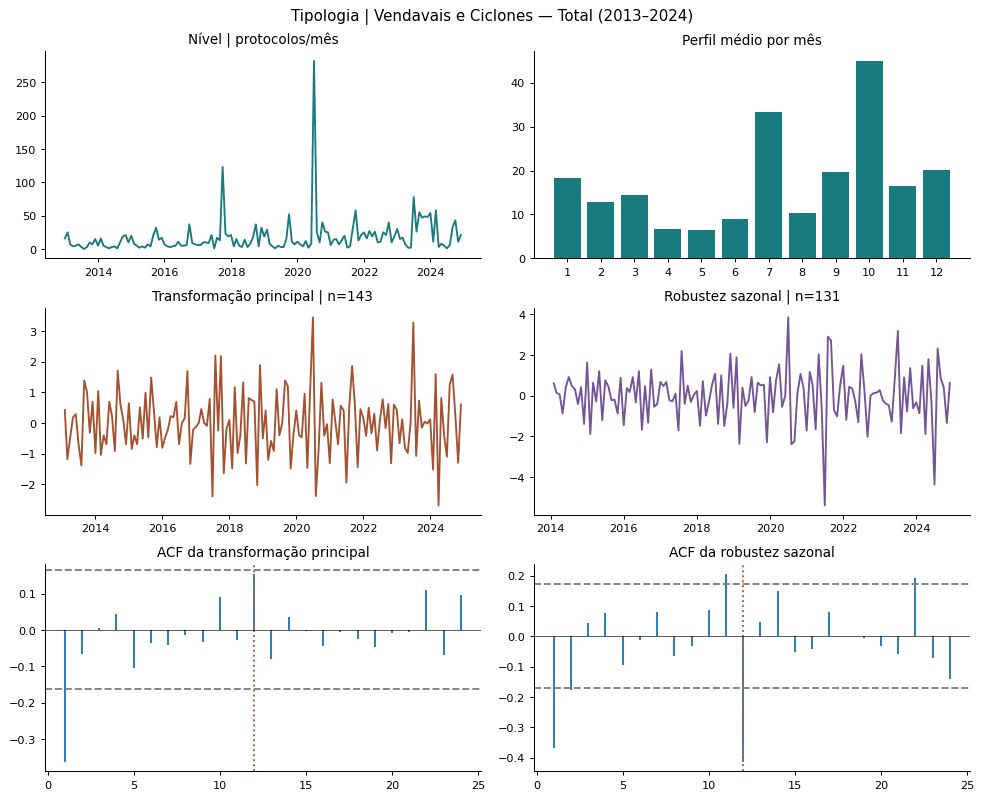

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
147,Nível,144,0,-10.871897,1.361818e-19,0,143,0.664379,0.016784,4,Interpolado,Conflitante: ambos rejeitam
148,Log,144,0,-7.942426,3.286724e-12,0,143,0.957502,0.010000,5,"p ≤ 0,01",Conflitante: ambos rejeitam
149,Primeira diferença,143,1,-7.044740,5.725361e-10,7,135,0.110539,0.100000,31,"p ≥ 0,10",Estacionária: convergente
150,Diferença do log,143,1,-7.759775,9.523113e-12,10,132,0.100998,0.100000,20,"p ≥ 0,10",Estacionária: convergente
151,Diferença sazonal,132,12,-5.889546,2.946572e-07,11,120,0.041155,0.100000,1,"p ≥ 0,10",Estacionária: convergente
152,Diferença + sazonal,131,13,-4.864169,4.092968e-05,13,117,0.414117,0.071070,104,Interpolado,Estacionária: convergente
153,Diferença do log + sazonal,131,13,-4.725220,7.543639e-05,13,117,0.257101,0.100000,38,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=9.523e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=143.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=7.544e-05, KPSS p ≥ 0,10 (valor tabelado 0.1), n=131.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

### Tipologia | Vendavais e Ciclones — Pré-pandemia (até jan/2020)

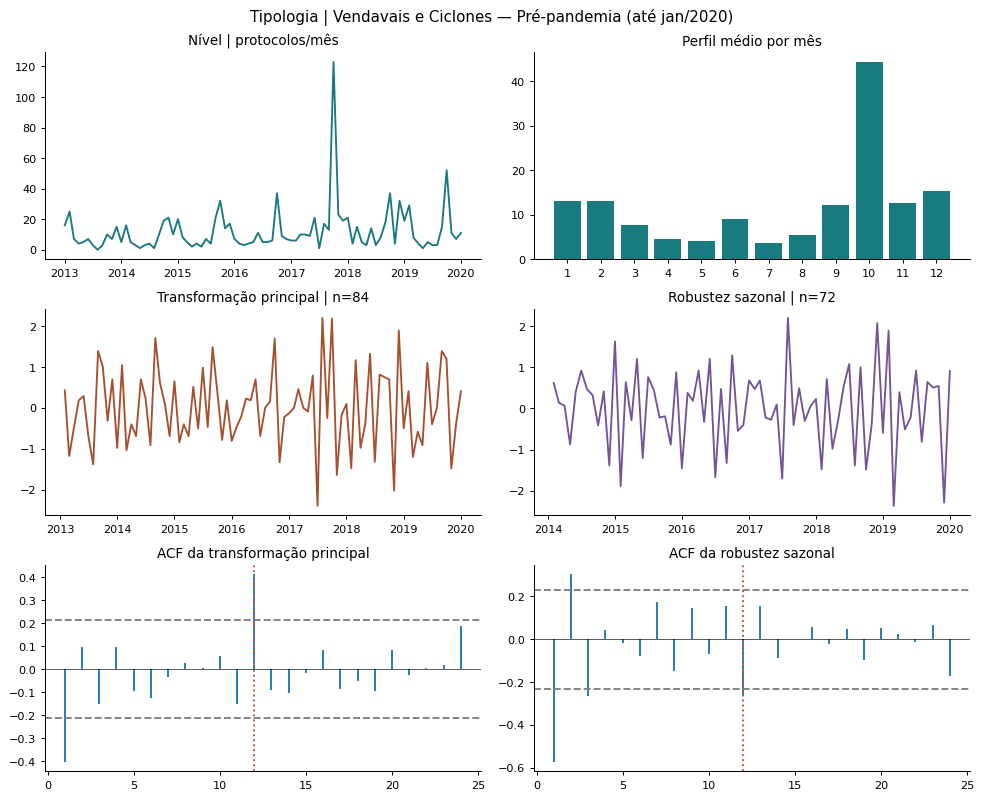

,Transformação,n,Perda meses,ADF estatística,ADF p,ADF lags,ADF n efetivo,KPSS estatística,KPSS p,KPSS lags,KPSS limite,Conclusão
301,Nível,85,0,-7.780059,8.464264e-12,0,84,0.304965,0.1,3,"p ≥ 0,10",Estacionária: convergente
302,Log,85,0,-1.287011,6.350935e-01,11,73,0.292582,0.1,4,"p ≥ 0,10",Inconclusiva: nenhum rejeita
303,Primeira diferença,84,1,-7.001905,7.285405e-10,10,73,0.082092,0.1,12,"p ≥ 0,10",Estacionária: convergente
304,Diferença do log,84,1,-7.784912,8.228798e-12,10,73,0.036735,0.1,5,"p ≥ 0,10",Estacionária: convergente
305,Diferença sazonal,73,12,-7.216403,2.167448e-10,0,72,0.104251,0.1,3,"p ≥ 0,10",Estacionária: convergente
306,Diferença + sazonal,72,13,-3.495287,8.108973e-03,12,59,0.149448,0.1,16,"p ≥ 0,10",Estacionária: convergente
307,Diferença do log + sazonal,72,13,-5.920246,2.516427e-07,5,66,0.042784,0.1,1,"p ≥ 0,10",Estacionária: convergente


**Diferença do log:** Estacionária: convergente; ADF p=8.229e-12, KPSS p ≥ 0,10 (valor tabelado 0.1), n=84.

**Diferença do log + sazonal:** Estacionária: convergente; ADF p=2.516e-07, KPSS p ≥ 0,10 (valor tabelado 0.1), n=72.

Os testes convergem nas duas transformações de referência. Isso apoia a modelagem, mas não dispensa os diagnósticos residuais nem prova estabilidade estrutural.

In [5]:
for key in ['Inadimplência'] + meta.Chave.tolist():
    for periodo in PERIODOS:
        display(Markdown('### '+key+' — '+periodo))
        figura_est(series,key,periodo)
        tabela(testes[(testes.Chave==key)&(testes.Período==periodo)][['Transformação','n','Perda meses','ADF estatística','ADF p','ADF lags','ADF n efetivo','KPSS estatística','KPSS p','KPSS lags','KPSS limite','Conclusão']])
        interpretar_est(testes,key,periodo)


## Resumo de elegibilidade e limitações

Séries raras permanecem nas tabelas, mas são excluídas da inferência Granger convencional. O ADF/KPSS pode ser pouco informativo em contagens esparsas. A agregação nacional não permite verificar modalidades do SCR na origem.

In [6]:
tabela(cobertura[(cobertura.Nível!='Crédito') & ~cobertura['Elegível Granger']])
tabela(testes.groupby(['Período','Transformação','Conclusão']).size().reset_index(name='Quantidade de séries'))

,Período,Chave,Nível,Categoria,Meses,Início,Fim,Total ocorrências,Meses com ocorrência,Proporção zeros,Média,Desvio-padrão,Variância,Valores distintos,Rara,Elegível Granger,Cobertura
38,Pré-pandemia (até jan/2020),Tipologia | Onda de Calor e Baixa Umidade,Tipologia,Onda de Calor e Baixa Umidade,85,2013-01-01,2020-01-01,19.0,14,0.835294,0.223529,0.661464,0.437535,4,True,False,Extração disponível; notificação completa não certificada
41,Pré-pandemia (até jan/2020),Tipologia | Rompimento/Colapso de barragens,Tipologia,Rompimento/Colapso de barragens,85,2013-01-01,2020-01-01,15.0,6,0.929412,0.176471,0.888772,0.789916,4,True,False,Extração disponível; notificação completa não certificada


,Período,Transformação,Conclusão,Quantidade de séries
0,Pré-pandemia (até jan/2020),Diferença + sazonal,Conflitante: ambos rejeitam,2
1,Pré-pandemia (até jan/2020),Diferença + sazonal,Estacionária: convergente,18
2,Pré-pandemia (até jan/2020),Diferença + sazonal,Inconclusiva: nenhum rejeita,2
3,Pré-pandemia (até jan/2020),Diferença do log,Estacionária: convergente,21
4,Pré-pandemia (até jan/2020),Diferença do log,Inconclusiva: nenhum rejeita,1
5,Pré-pandemia (até jan/2020),Diferença do log + sazonal,Estacionária: convergente,18
6,Pré-pandemia (até jan/2020),Diferença do log + sazonal,Inconclusiva: nenhum rejeita,4
7,Pré-pandemia (até jan/2020),Diferença sazonal,Estacionária: convergente,18
8,Pré-pandemia (até jan/2020),Diferença sazonal,Inconclusiva: nenhum rejeita,3
9,Pré-pandemia (até jan/2020),Diferença sazonal,Não estacionária: convergente,1
